# Практичне завдання 2: Логістична регресія та федеративне навчання

**Датасет:** Dry Bean Dataset (7 класів, 16 числових ознак)  
**Інструменти:** NumPy, Pandas, Matplotlib, Scikit-learn (лише метрики, стратифіковане розбиття, допоміжні функції)  
**Модель:** багатокласова логістична регресія (softmax), реалізована самостійно на NumPy  
**Федеративне навчання:** FedAvg, симуляція на одному комп'ютері

Порядок роботи (за методичкою): **спочатку розбиття** на Global Test / Global Validation / FL Train Pool, **потім** відбір ознак, масштабування та будь-які інші операції, що навчаються на даних, тільки на FL Train Pool.

Для кожного графіка й таблиці нижче наведено висновок: що показано, яка закономірність, чому так, як це впливає на вибір моделі/гіперпараметрів.

## 0. Імпорти та налаштування

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, balanced_accuracy_score,
    log_loss, confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Поклади Dry_Bean_Dataset.arff поруч із ноутбуком (або вкажи свій шлях)
DATA_PATH = next((Path(p) for p in ["Dry_Bean_Dataset.arff", "/mnt/user-data/uploads/Dry_Bean_Dataset.arff",
                                    "/kaggle/input/dry-bean-dataset/Dry_Bean_Dataset.arff"] if Path(p).exists()),
                 Path("Dry_Bean_Dataset.arff"))
print("NumPy:", np.__version__)
print("Data path:", DATA_PATH)

NumPy: 2.4.4
Data path: Dry_Bean_Dataset.arff


## 1. Завантаження датасету та обґрунтування вибору

Обрано **Dry Bean Dataset**:

* **багатокласова задача**: 7 класів (Barbunya, Bombay, Cali, Dermason, Horoz, Seker, Sira), що більше мінімуму в 3 класи;
* **достатній обсяг**: ≈13 тис. прикладів, навіть при 10 клієнтах у кожного залишаються сотні прикладів;
* **числові ознаки без пропусків**, тому акцент на методиці, а не на очищенні даних;
* **природна федеративна інтерпретація**: різні елеватори / ферми / сортувальні станції мають власні зображення зерна, якими не хочуть ділитися, і закономірно мають різні сорти (Non-IID за класами);
* **дисбаланс класів** (Bombay ≈ 4% проти Dermason ≈ 26%) дозволяє обґрунтувати macro-F1 та balanced accuracy.

In [2]:
def load_arff_simple(path):
    # Простий ARFF-завантажувач без використання готової ML-моделі.
    attributes = []
    data_started = False
    rows = []

    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for raw_line in f:
            line = raw_line.strip()

            if not line or line.startswith("%"):
                continue

            lower = line.lower()

            if lower.startswith("@attribute"):
                parts = line.split(maxsplit=2)
                if len(parts) >= 3:
                    # ВИПРАВЛЕНО: у оригіналі було strip("'"") - синтаксична помилка
                    name = parts[1].strip().strip("'").strip('"')
                    attributes.append(name)

            elif lower.startswith("@data"):
                data_started = True

            elif data_started:
                values = [x.strip().strip("'").strip('"') for x in line.split(",")]
                rows.append(values)

    return pd.DataFrame(rows, columns=attributes)


df = load_arff_simple(DATA_PATH)

feature_columns = [c for c in df.columns if c != "Class"]
for col in feature_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Shape:", df.shape)
display(df.head())

Shape: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


### Висновок

Завантажено 13 611 рядків × 17 стовпців: 16 числових ознак і цільова змінна `Class` (7 сортів). У початковому завантажувачі був синтаксичний помилковий рядок `strip("'"")`, через який ноутбук не запускався взагалі; виправлено.

## 2. Первинний аналіз даних (EDA)

Структура, типи, пропуски, дублікати, розподіл класів, основні статистики. Це **описова** статистика (нічого не навчається), тому її допустимо робити на всіх даних. **Кореляційний аналіз для відбору ознак** робимо пізніше, вже на FL Train Pool.

In [3]:
print("Типи даних:")
display(df.dtypes.to_frame("dtype").T)

print("Пропущені значення (всього):", int(df.isna().sum().sum()))

n_dup = int(df.duplicated().sum())
print("Повних дублікатів рядків:", n_dup)
# Дублікати прибираємо ДО розбиття: інакше однакові рядки можуть потрапити і в train, і в test
df = df.drop_duplicates().reset_index(drop=True)
print("Shape після видалення дублікатів:", df.shape)

print("\nОсновні статистики:")
display(df[feature_columns].describe().T.round(3))

Типи даних:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
dtype,int64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str


Пропущені значення (всього): 0
Повних дублікатів рядків: 68
Shape після видалення дублікатів: (13543, 17)

Основні статистики:


,count,mean,std,min,25%,50%,75%,max
Area,13543.0,53048.460,29392.438,20420.000,36282.500,44580.000,61382.000,254616.000
Perimeter,13543.0,854.993,214.723,524.736,703.230,793.896,977.147,1985.370
MajorAxisLength,13543.0,319.896,85.809,183.601,253.087,296.405,376.312,738.860
MinorAxisLength,13543.0,202.365,45.052,122.513,175.886,192.491,217.245,460.198
AspectRation,13543.0,1.581,0.245,1.025,1.431,1.550,1.704,2.430
Eccentricity,13543.0,0.750,0.092,0.219,0.715,0.764,0.810,0.911
ConvexArea,13543.0,53767.987,29844.249,20684.000,36673.000,45122.000,62360.000,263261.000
EquivDiameter,13543.0,253.034,59.308,161.244,214.933,238.246,279.560,569.374
Extent,13543.0,0.750,0.049,0.555,0.719,0.760,0.787,0.866
Solidity,13543.0,0.987,0.005,0.919,0.986,0.988,0.990,0.995


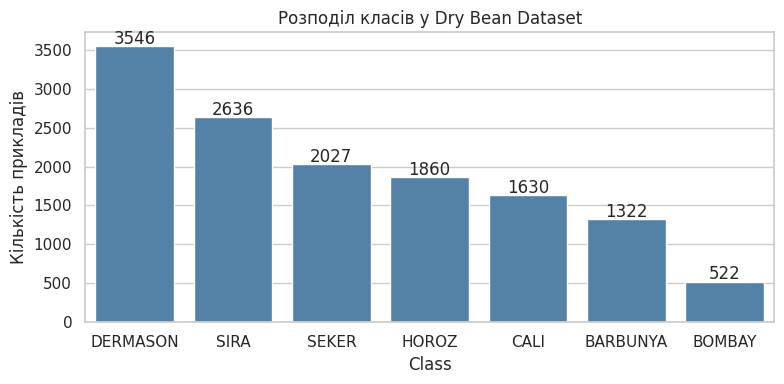

Кількість класів: 7
Відношення найбільшого класу до найменшого: 6.8


In [4]:
class_counts = df["Class"].value_counts()

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=class_counts.index, y=class_counts.values, color="steelblue")
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 30, str(v), ha="center")
plt.title("Розподіл класів у Dry Bean Dataset")
plt.xlabel("Class"); plt.ylabel("Кількість прикладів")
plt.tight_layout(); plt.show()

print("Кількість класів:", df["Class"].nunique())
print("Відношення найбільшого класу до найменшого: %.1f" % (class_counts.max() / class_counts.min()))

### Висновок

* Пропусків немає, типи коректні (усі ознаки числові).
* Знайдено **68 повних дублікатів**: їх видалено до розбиття (13 543 рядки), щоб однакові приклади не потрапили одночасно в train і test.
* Класи **незбалансовані**: найбільший до найменшого ≈ 6,8 (Dermason проти Bombay). Тому поряд з accuracy використовуємо macro-F1 та balanced accuracy.
* Ознаки мають різні масштаби (Area ≈ 5·10⁴, ShapeFactor1 ≈ 0,007), тож для градієнтного спуску стандартизація обов'язкова: без неї кроки по різних ознаках були б непорівнянні.

## 3. Кодування цільової змінної

Усі 16 ознак **числові**, категоріальних вхідних ознак немає, тому One-Hot / Ordinal / Target Encoding до ознак **не застосовуються** (Target Encoding до того ж створив би додатковий ризик leakage). Кодуємо лише цільову змінну `Class`: `LabelEncoder` → індекси 0..6, далі One-Hot (див. п. 7) для формули крос-ентропії. Ці індекси лише ідентифікатори класів, а не порядок.

In [5]:
label_encoder = LabelEncoder()
y_all = label_encoder.fit_transform(df["Class"].values)
class_names = label_encoder.classes_
n_classes = len(class_names)

X_all = df[feature_columns].values.astype(float)

print("Класи:")
for i, name in enumerate(class_names):
    print(i, "->", name)

Класи:
0 -> BARBUNYA
1 -> BOMBAY
2 -> CALI
3 -> DERMASON
4 -> HOROZ
5 -> SEKER
6 -> SIRA


## 4. Розбиття даних

Схема (стратифіковано за класами):

```
Усі дані (100%)
├── Global Test        20%  - тільки у сервера, лише для фінальної оцінки
├── Global Validation  10%  - тільки у сервера, підбір гіперпараметрів, моніторинг раундів
└── FL Train Pool      70%  - єдина частина, що розподіляється між клієнтами
```

**Чому розбиття має бути до масштабування, кодування, відбору ознак?** Усе, що *навчається* на даних (середнє й дисперсія скалера, кореляційний відбір, target encoding), використовує статистику вибірки. Якщо порахувати її на всіх даних, інформація про тест «просочується» в навчання: це **Data Leakage**. Оцінка якості стає завищеною й не відображає поведінку на нових даних.

FL Train Pool: (9479, 16)
Global Validation: (1355, 16)
Global Test: (2709, 16)
Частки: [0.7, 0.1, 0.2]


,FL Train Pool,Global Validation,Global Test
BARBUNYA,925,132,265
BOMBAY,366,52,104
CALI,1141,163,326
DERMASON,2482,355,709
HOROZ,1302,186,372
SEKER,1418,203,406
SIRA,1845,264,527


,"FL Train Pool, частка класу","Global Validation, частка класу","Global Test, частка класу"
BARBUNYA,0.098,0.097,0.098
BOMBAY,0.039,0.038,0.038
CALI,0.120,0.120,0.120
DERMASON,0.262,0.262,0.262
HOROZ,0.137,0.137,0.137
SEKER,0.150,0.150,0.150
SIRA,0.195,0.195,0.195


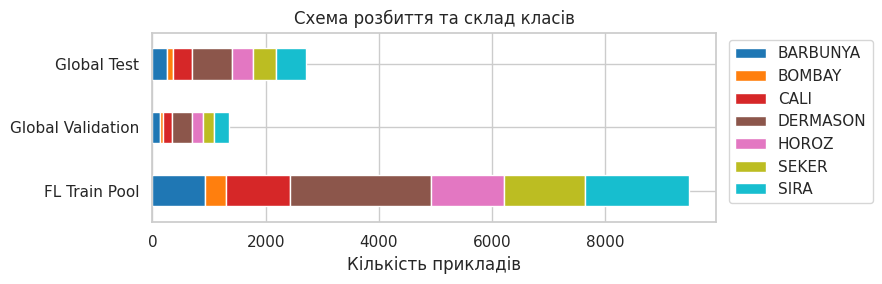

In [6]:
X_pool, X_test, y_pool, y_test = train_test_split(
    X_all, y_all, test_size=0.20, stratify=y_all, random_state=RANDOM_STATE
)
# X_pool/y_pool тут = (FL Train Pool + Global Validation); відділяємо 10% від усіх даних
X_train, X_val, y_train, y_val = train_test_split(
    X_pool, y_pool, test_size=0.125, stratify=y_pool, random_state=RANDOM_STATE
)

print("FL Train Pool:", X_train.shape)
print("Global Validation:", X_val.shape)
print("Global Test:", X_test.shape)
print("Частки:", [round(len(a) / len(X_all), 3) for a in (X_train, X_val, X_test)])

split_tbl = pd.DataFrame({
    "FL Train Pool": np.bincount(y_train, minlength=n_classes),
    "Global Validation": np.bincount(y_val, minlength=n_classes),
    "Global Test": np.bincount(y_test, minlength=n_classes)}, index=class_names)
display(split_tbl)
display((split_tbl / split_tbl.sum()).round(3).rename(columns=lambda c: c + ", частка класу"))
split_tbl.T.plot(kind="barh", stacked=True, figsize=(9, 3), colormap="tab10")
plt.title("Схема розбиття та склад класів"); plt.xlabel("Кількість прикладів")
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left"); plt.tight_layout(); plt.show()

### Висновок

Розбиття 70/10/20 стратифіковане: частки кожного класу практично однакові в усіх трьох частинах (наприклад, Bombay ≈ 3,8–3,9% скрізь). Тому метрики на валідації та тесті порівнянні між собою, а FL Train Pool (9 479 прикладів) репрезентативний. Лише ця частина далі розподіляється між клієнтами.

## 5. Відбір ознак (лише на FL Train Pool)

1. **Зв'язок із таргетом**: частка поясненої дисперсії $\eta^2 = SS_{between}/SS_{total}$ (ANOVA-стиль).
2. **Мультиколінеарність**: для пар з $|r|>0.95$ залишаємо ознаку, яка сильніше пов'язана з таргетом. Сильно колінеарні ознаки роблять ваги нестабільними та ускладнюють інтерпретацію (тут багато ознак алгебраїчно пов'язані: Area, ConvexArea, EquivDiameter, Perimeter...).

> Оригінальна версія будувала кореляції на **всьому** датасеті (включно з тестом) і взагалі не робила відбору. Виправлено: аналіз тільки на FL Train Pool.

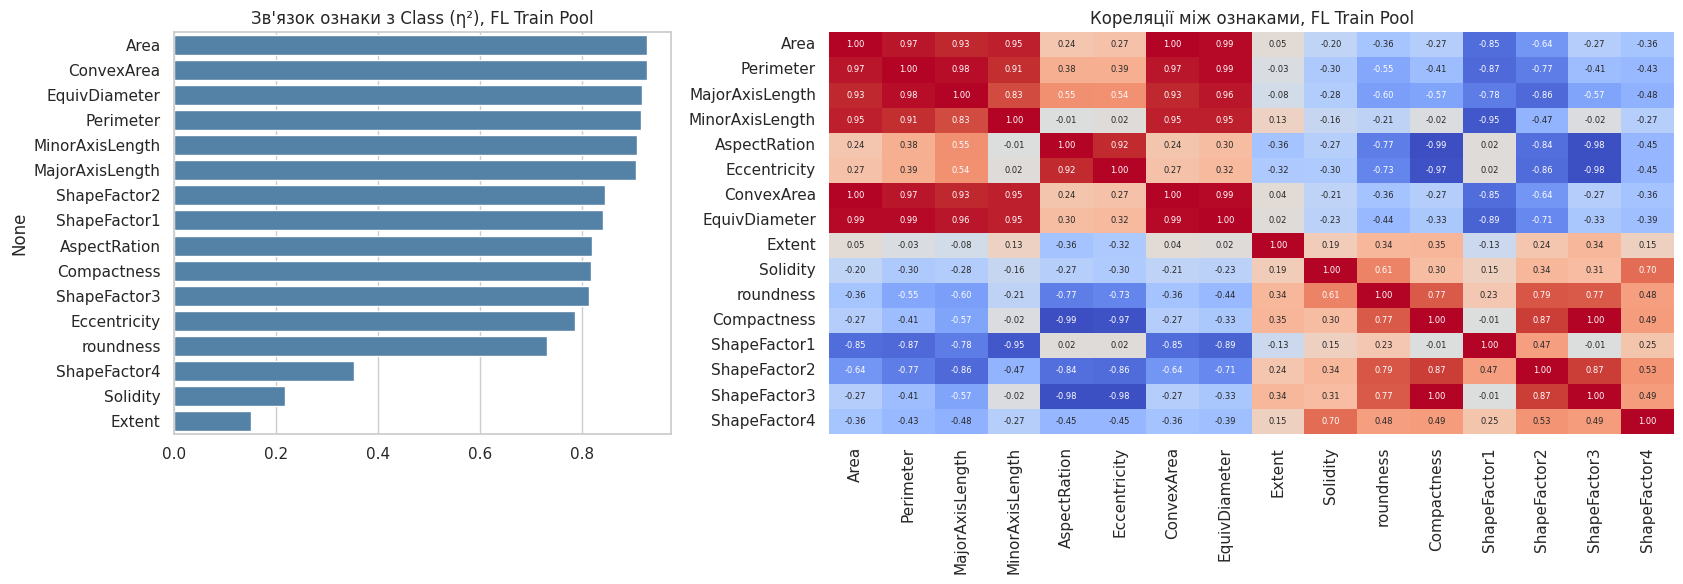

Залишено (10): ['Area', 'MajorAxisLength', 'ShapeFactor2', 'ShapeFactor1', 'AspectRation', 'Eccentricity', 'roundness', 'ShapeFactor4', 'Solidity', 'Extent']
  відкинуто ConvexArea       r = +1.000 з Area
  відкинуто EquivDiameter    r = +0.985 з Area
  відкинуто Perimeter        r = +0.967 з Area
  відкинуто MinorAxisLength  r = +0.953 з Area
  відкинуто Compactness      r = -0.988 з AspectRation
  відкинуто ShapeFactor3     r = -0.978 з AspectRation
Форма після відбору: (9479, 10)


In [7]:
X_train_df = pd.DataFrame(X_train, columns=feature_columns)

def eta_squared(X, y):
    grand = X.mean(0)
    ssb = sum((y == c).sum() * (X[y == c].mean(0) - grand) ** 2 for c in np.unique(y))
    return ssb / ((X - grand) ** 2).sum(0)

eta2 = pd.Series(eta_squared(X_train, y_train), index=feature_columns).sort_values(ascending=False)
corr = X_train_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw={"width_ratios": [1, 1.7]})
sns.barplot(x=eta2.values, y=eta2.index, ax=axes[0], color="steelblue")
axes[0].set_title("Зв'язок ознаки з Class (η²), FL Train Pool")
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1], annot_kws={"size": 6}, cbar=False)
axes[1].set_title("Кореляції між ознаками, FL Train Pool")
plt.tight_layout(); plt.show()

CORR_THRESHOLD = 0.95
selected, dropped = [], {}
for f in eta2.index:                       # від найінформативнішої до найменш інформативної
    clash = [(s, corr.loc[f, s]) for s in selected if abs(corr.loc[f, s]) > CORR_THRESHOLD]
    if clash: dropped[f] = clash[0]
    else: selected.append(f)

print("Залишено (%d):" % len(selected), selected)
for f, (s, r) in dropped.items():
    print("  відкинуто %-16s r = %+.3f з %s" % (f, r, s))

sel_idx = [feature_columns.index(f) for f in selected]
X_train, X_val, X_test = X_train[:, sel_idx], X_val[:, sel_idx], X_test[:, sel_idx]
feature_columns_sel = selected
print("Форма після відбору:", X_train.shape)

### Висновок

Із 16 ознак залишено 10. Відкинуто: `ConvexArea` (r = 1,000 з `Area`), `EquivDiameter` (0,985), `Perimeter` (0,967), `MinorAxisLength` (0,953), `Compactness` (−0,988 з `AspectRation`), `ShapeFactor3` (−0,978 з `AspectRation`). Причина: розмірні ознаки зерна майже лінійно виражаються одна через одну (площа, периметр, діаметр), а Compactness / ShapeFactor3 фактично є функціями відношення осей. Така колінеарність не додає інформації, але робить ваги нестабільними. У кожній парі залишено ознаку з більшим η² відносно класу. Поріг 0,95 задано заздалегідь, аналіз зроблено лише на FL Train Pool.

## 6. Масштабування

Використовуємо **спрощений підхід (а)** з методички: стандартизація навчається на FL Train Pool **до розподілу між клієнтами**; це частина симуляції. Параметри застосовуються до Validation і Test. Тест у розрахунку не бере участі.

Нижче показано, що «більш федеративний» підхід (б) дає **ті самі** $\mu,\sigma$: клієнти рахують локальні $n_k,\mu_k,\sigma_k^2$, сервер об'єднує їх точно.

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Середні (train, ≈0):", np.round(X_train_scaled.mean(0), 6))
print("Std (train, ≈1):", np.round(X_train_scaled.std(0), 3))
print("Середні (test, не обов'язково 0):", np.round(X_test_scaled.mean(0), 3))

# --- підхід (б): федеративна агрегація статистик ---
def local_stats(X): return len(X), X.mean(0), X.var(0)          # робить клієнт
def aggregate_stats(stats):                                      # робить сервер
    n = np.array([s[0] for s in stats], float)
    mus = np.stack([s[1] for s in stats]); vs = np.stack([s[2] for s in stats])
    mu = (n[:, None] * mus).sum(0) / n.sum()
    var = (n[:, None] * (vs + (mus - mu) ** 2)).sum(0) / n.sum()
    return mu, np.sqrt(var)

chunks = np.array_split(np.random.default_rng(0).permutation(len(X_train)), 7)   # довільні нерівні клієнти
mu_fed, sd_fed = aggregate_stats([local_stats(X_train[c]) for c in chunks])
assert np.allclose(mu_fed, scaler.mean_) and np.allclose(sd_fed, scaler.scale_)
print("\nФедеративна агрегація статистик == StandardScaler на всьому пулі ✓")

Середні (train, ≈0): [ 0.  0.  0.  0.  0. -0. -0. -0.  0.  0.]
Std (train, ≈1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Середні (test, не обов'язково 0): [ 0.004  0.005 -0.005 -0.004  0.004  0.003 -0.015  0.011 -0.004 -0.004]

Федеративна агрегація статистик == StandardScaler на всьому пулі ✓


## 7. One-hot encoding таргета

In [9]:
def one_hot(y, n_classes):
    result = np.zeros((len(y), n_classes), dtype=float)
    result[np.arange(len(y)), y] = 1.0
    return result

Y_train = one_hot(y_train, n_classes)
Y_val = one_hot(y_val, n_classes)
Y_test = one_hot(y_test, n_classes)
print("Y_train shape:", Y_train.shape)

Y_train shape: (9479, 7)


# 8. Власна багатокласова логістична регресія

$$Z=XW+b,\quad P=\mathrm{softmax}(Z),\quad J=-\frac1m\sum_{i,c}Y_{ic}\log P_{ic}+\frac{\lambda}{2}\|W\|_F^2$$

$$\frac{\partial J}{\partial W}=\frac1m X^\top(P-Y)+\lambda W,\qquad \frac{\partial J}{\partial b}=\frac1m\mathbf 1^\top(P-Y)$$

Цикли `for` лише по епохах / міні-батчах / клієнтах; по прикладах немає. $b$ не регуляризується.

> **Критичну помилку виправлено.** У початковій реалізації `fit()` на початку завжди обнуляв `W` і `b` (`self.W = np.zeros(...)`), тому `set_params(global)` перед `fit()` **втрачався**: у кожному раунді кожен клієнт навчався з нуля, а сервер усереднював такі моделі. Це не FedAvg. Тепер `fit(..., warm_start=True)` продовжує з наявних параметрів. Також `loss` рахується через стабільний log-softmax (без `log(P+eps)`).

In [10]:
class MulticlassLogisticRegression:
    def __init__(self, learning_rate=0.05, epochs=100, batch_size=128,
                 reg_lambda=0.0, random_state=42):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.reg_lambda = reg_lambda
        self.random_state = random_state

        self.W = None
        self.b = None
        self.loss_history = []        # train loss (з регуляризацією) по епохах
        self.val_loss_history = []    # validation cross-entropy по епохах
        self.val_acc_history = []

    # ---------- softmax ----------
    @staticmethod
    def softmax(z):
        z_shifted = z - np.max(z, axis=1, keepdims=True)      # віднімання максимуму рядка
        exp_z = np.exp(z_shifted)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    @staticmethod
    def log_softmax(z):
        z_shifted = z - np.max(z, axis=1, keepdims=True)
        return z_shifted - np.log(np.sum(np.exp(z_shifted), axis=1, keepdims=True))

    # ---------- прогноз ----------
    def predict_proba(self, X):
        return self.softmax(X @ self.W + self.b)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

    # ---------- функція втрат ----------
    def loss(self, X, Y, regularize=True):
        cross_entropy = -np.mean(np.sum(Y * self.log_softmax(X @ self.W + self.b), axis=1))
        ridge = (self.reg_lambda / 2.0) * np.sum(self.W ** 2) if regularize else 0.0
        return cross_entropy + ridge

    # ---------- градієнти ----------
    def gradients(self, X, Y):
        m = X.shape[0]
        error = self.predict_proba(X) - Y
        dW = (X.T @ error) / m + self.reg_lambda * self.W      # b не регуляризується
        db = np.mean(error, axis=0)
        return dW, db

    # ---------- оновлення параметрів ----------
    def update_params(self, dW, db):
        self.W -= self.learning_rate * dW
        self.b -= self.learning_rate * db

    def init_params(self, n_features, n_classes_local):
        self.W = np.zeros((n_features, n_classes_local))
        self.b = np.zeros(n_classes_local)

    # ---------- міні-батчевий градієнтний спуск ----------
    def fit(self, X, Y, X_val=None, Y_val=None, warm_start=False, record=True, verbose=False):
        rng = np.random.default_rng(self.random_state)
        n_samples, n_features = X.shape

        if (not warm_start) or self.W is None:      # ключове виправлення: warm start зберігає отримані від сервера ваги
            self.init_params(n_features, Y.shape[1])
        self.loss_history, self.val_loss_history, self.val_acc_history = [], [], []

        for epoch in range(self.epochs):
            indices = rng.permutation(n_samples)
            for start in range(0, n_samples, self.batch_size):
                batch = indices[start:start + self.batch_size]
                dW, db = self.gradients(X[batch], Y[batch])
                self.update_params(dW, db)

            if record:
                current_loss = self.loss(X, Y)
                self.loss_history.append(current_loss)
                if X_val is not None:
                    self.val_loss_history.append(self.loss(X_val, Y_val, regularize=False))
                    self.val_acc_history.append(np.mean(self.predict(X_val) == np.argmax(Y_val, axis=1)))
                if verbose and (epoch == 0 or (epoch + 1) % 20 == 0):
                    print(f"Epoch {epoch + 1:3d}/{self.epochs}, loss = {current_loss:.5f}")
        return self

    def get_params(self):
        return self.W.copy(), self.b.copy()

    def set_params(self, W, b):
        self.W = W.copy()
        self.b = b.copy()
        return self

## 8.1 Перевірка softmax та градієнтів

In [11]:
test_model = MulticlassLogisticRegression()
test_model.W = np.random.randn(X_train_scaled.shape[1], n_classes) * 0.01
test_model.b = np.zeros(n_classes)
sample_probs = test_model.predict_proba(X_train_scaled[:5])
print("Суми рядків softmax:", sample_probs.sum(axis=1))

# стабільність: величезні логіти не дають NaN/inf
big = MulticlassLogisticRegression.softmax(np.array([[1000., 1001., 999.]]))
print("softmax для логітів ~1000:", big, "| NaN:", bool(np.isnan(big).any()))

# числова перевірка градієнтів (центральні різниці)
rng = np.random.default_rng(1)
sub = rng.choice(len(X_train_scaled), 200, replace=False)
gm = MulticlassLogisticRegression(reg_lambda=0.05)
gm.W = rng.normal(0, .3, (X_train_scaled.shape[1], n_classes)); gm.b = rng.normal(0, .1, n_classes)
dW, db = gm.gradients(X_train_scaled[sub], Y_train[sub])
eps, errs = 1e-6, []
def rel(a, b): return abs(a - b) / max(1e-12, abs(a) + abs(b))
for _ in range(25):
    i, j = rng.integers(gm.W.shape[0]), rng.integers(n_classes); old = gm.W[i, j]
    gm.W[i, j] = old + eps; Jp = gm.loss(X_train_scaled[sub], Y_train[sub])
    gm.W[i, j] = old - eps; Jm = gm.loss(X_train_scaled[sub], Y_train[sub]); gm.W[i, j] = old
    errs.append(rel((Jp - Jm) / (2 * eps), dW[i, j]))
for j in range(n_classes):
    old = gm.b[j]
    gm.b[j] = old + eps; Jp = gm.loss(X_train_scaled[sub], Y_train[sub])
    gm.b[j] = old - eps; Jm = gm.loss(X_train_scaled[sub], Y_train[sub]); gm.b[j] = old
    errs.append(rel((Jp - Jm) / (2 * eps), db[j]))
print("Макс. відносна похибка аналітичних градієнтів: %.2e" % max(errs))
assert max(errs) < 1e-5

Суми рядків softmax: [1. 1. 1. 1. 1.]
softmax для логітів ~1000: [[0.24472847 0.66524096 0.09003057]] | NaN: False
Макс. відносна похибка аналітичних градієнтів: 7.30e-09


### Висновок

Суми рядків softmax = 1, а для логітів ≈ 1000 немає NaN/inf (віднімання максимуму працює). Максимальна відносна похибка аналітичних градієнтів порівняно з числовими ≈ 7·10⁻⁹, тому формули $\frac1m X^\top(P-Y)+\lambda W$ та $\frac1m\mathbf1^\top(P-Y)$ реалізовано правильно.

# 9. Центрально навчена базова модель

Гіперпараметри підбираємо **лише на Global Validation** у два кроки: (1) сітка *lr × batch size* при $\lambda=0$; (2) для кращої пари сітка за $\lambda$ (Ridge). Критерій вибору: validation log-loss (гладкий, чутливіший за accuracy). Global Test не використовується.

> Оригінал перебирав лише 3 вручну заданих конфігурації без дослідження впливу lr, batch size та Ridge окремо.

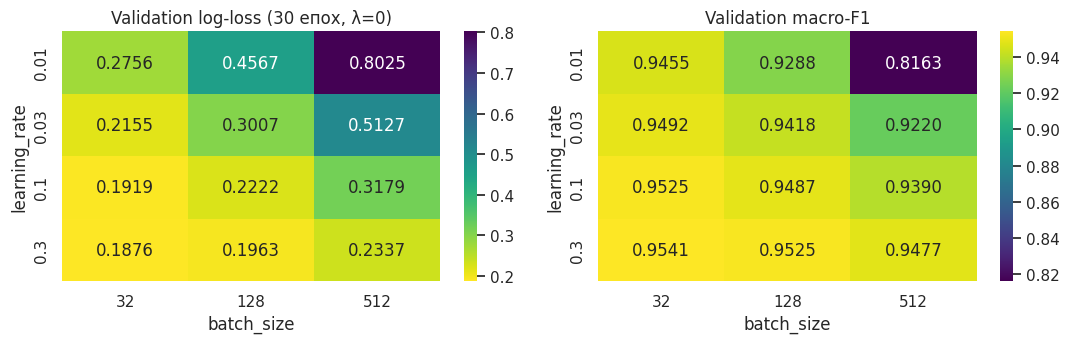

Обрано: learning_rate = 0.3 , batch_size = 32


In [12]:
def evaluate_model(model, X, y):
    probs = model.predict_proba(X)
    pred = np.argmax(probs, axis=1)
    return {
        "accuracy": accuracy_score(y, pred),
        "macro_f1": f1_score(y, pred, average="macro"),
        "balanced_accuracy": balanced_accuracy_score(y, pred),
        "log_loss": log_loss(y, probs, labels=np.arange(n_classes))
    }

EPOCHS_TUNE = 30
rows = []
for lr in [0.01, 0.03, 0.1, 0.3]:
    for bs in [32, 128, 512]:
        m = MulticlassLogisticRegression(lr, EPOCHS_TUNE, bs, 0.0, RANDOM_STATE).fit(X_train_scaled, Y_train)
        rows.append({"learning_rate": lr, "batch_size": bs, **evaluate_model(m, X_val_scaled, y_val)})
grid1 = pd.DataFrame(rows)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
sns.heatmap(grid1.pivot(index="learning_rate", columns="batch_size", values="log_loss"), annot=True, fmt=".4f", cmap="viridis_r", ax=ax[0])
ax[0].set_title(f"Validation log-loss ({EPOCHS_TUNE} епох, λ=0)")
sns.heatmap(grid1.pivot(index="learning_rate", columns="batch_size", values="macro_f1"), annot=True, fmt=".4f", cmap="viridis", ax=ax[1])
ax[1].set_title("Validation macro-F1")
plt.tight_layout(); plt.show()

best1 = grid1.sort_values("log_loss").iloc[0]
LR, BS = float(best1.learning_rate), int(best1.batch_size)
print("Обрано: learning_rate =", LR, ", batch_size =", BS)

### Висновок

За фіксованого бюджету 30 епох якість зростає зі збільшенням швидкості навчання та зменшенням батчу: найкраща пара **lr = 0,3, batch = 32** (val log-loss 0,1876, macro-F1 0,954), найгірша lr = 0,01, batch = 512 (log-loss 0,80). Причина: кількість кроків SGD ∝ епохи / розмір батчу, а за малих lr і великих батчів модель за 30 епох просто недонавчена. Оптимум лежить на межі сітки, тобто з більшим бюджетом епох різниця між комбінаціями зменшилась би. Для порівняльних експериментів нижче ця пара використовується як фіксована.

,reg_lambda,accuracy,macro_f1,balanced_accuracy,log_loss,||W||_F
0,0.0000,0.9439,0.9541,0.9524,0.1876,15.3281
1,0.0001,0.9424,0.9529,0.9511,0.1900,14.1988
2,0.0010,0.9402,0.9512,0.9494,0.2135,10.1635
3,0.0100,0.9314,0.9422,0.9391,0.3435,5.5048
4,0.1000,0.8384,0.8407,0.8260,0.7478,2.2610


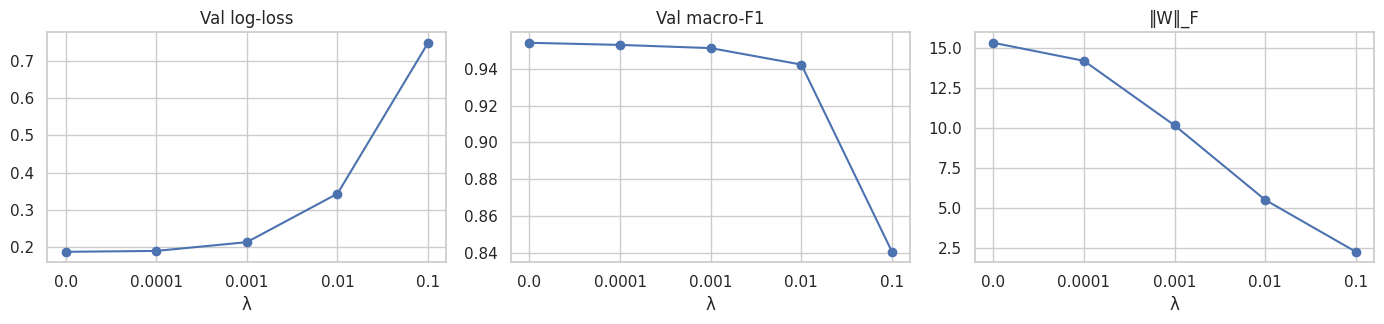

Найкращі параметри (за Global Validation): {'learning_rate': 0.3, 'batch_size': 32, 'reg_lambda': 0.0}


In [13]:
rows = []
for lam in [0.0, 1e-4, 1e-3, 1e-2, 1e-1]:
    m = MulticlassLogisticRegression(LR, EPOCHS_TUNE, BS, lam, RANDOM_STATE).fit(X_train_scaled, Y_train)
    rows.append({"reg_lambda": lam, **evaluate_model(m, X_val_scaled, y_val), "||W||_F": np.linalg.norm(m.W)})
validation_df = pd.DataFrame(rows)
display(validation_df.round(4))

fig, ax = plt.subplots(1, 3, figsize=(14, 3.4)); xs = np.arange(len(validation_df))
for a, col, t in zip(ax, ["log_loss", "macro_f1", "||W||_F"], ["Val log-loss", "Val macro-F1", "‖W‖_F"]):
    a.plot(xs, validation_df[col], "o-"); a.set_xticks(xs); a.set_xticklabels(validation_df.reg_lambda); a.set_xlabel("λ"); a.set_title(t)
plt.tight_layout(); plt.show()

best_row = validation_df.sort_values("log_loss").iloc[0]
best_params = {"learning_rate": LR, "batch_size": BS, "reg_lambda": float(best_row["reg_lambda"])}
print("Найкращі параметри (за Global Validation):", best_params)

### Висновок

Ridge **не покращує** якість на цих даних: val log-loss зростає з 0,1876 (λ = 0) до 0,1900 (10⁻⁴), 0,2135 (10⁻³), 0,3435 (10⁻²) і 0,7478 (10⁻¹), а норма ваг ‖W‖ падає з 15,3 до 2,3. Модель має лише 10 ознак при ≈ 9,5 тис. прикладів, переобучення немає (див. наступний графік), тож регуляризація лише зміщує оцінки (недонавчання). Обрано λ = 0 за валідацією. Це не означає, що Ridge «зайвий» взагалі: при малій вибірці, колінеарних ознаках або у клієнтів із малим n_k він був би корисним.

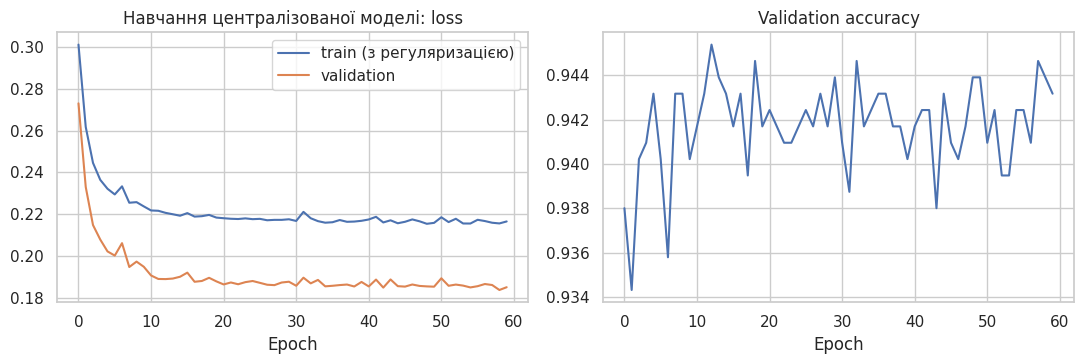

,accuracy,macro_f1,balanced_accuracy,log_loss
Centralized (Global Test),0.9155,0.9272,0.9269,0.2222


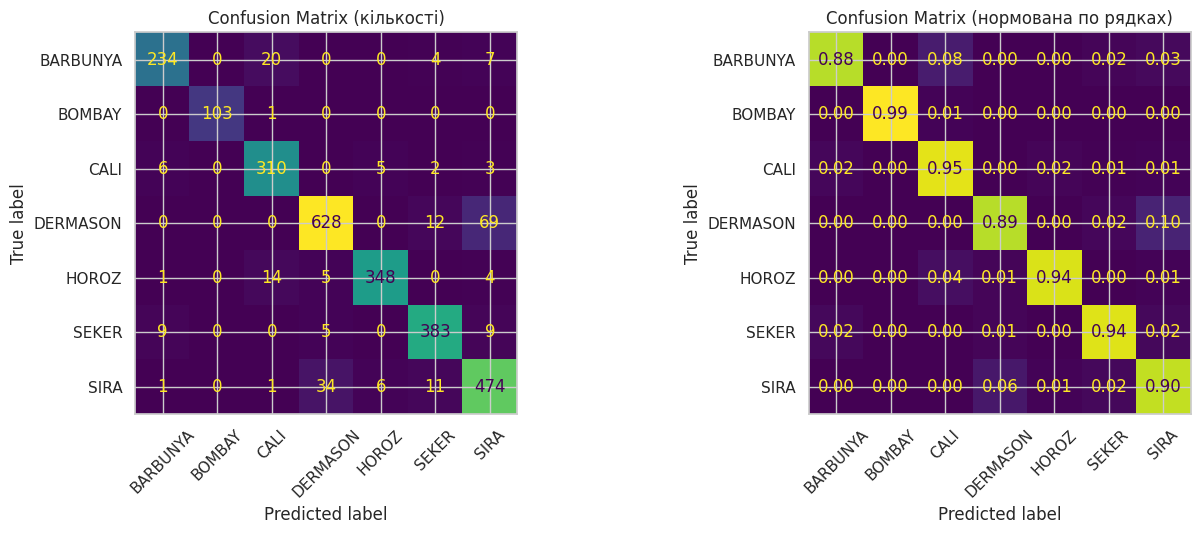

In [14]:
EPOCHS_CENTRAL = 60
central_model = MulticlassLogisticRegression(
    learning_rate=best_params["learning_rate"], epochs=EPOCHS_CENTRAL,
    batch_size=best_params["batch_size"], reg_lambda=best_params["reg_lambda"], random_state=RANDOM_STATE
).fit(X_train_scaled, Y_train, X_val_scaled, Y_val)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(central_model.loss_history, label="train (з регуляризацією)")
ax[0].plot(central_model.val_loss_history, label="validation")
ax[0].set_title("Навчання централізованої моделі: loss"); ax[0].set_xlabel("Epoch"); ax[0].legend()
ax[1].plot(central_model.val_acc_history); ax[1].set_title("Validation accuracy"); ax[1].set_xlabel("Epoch")
plt.tight_layout(); plt.show()

central_test_metrics = evaluate_model(central_model, X_test_scaled, y_test)
central_val_metrics = evaluate_model(central_model, X_val_scaled, y_val)
display(pd.DataFrame([central_test_metrics], index=["Centralized (Global Test)"]).round(4))

cm = confusion_matrix(y_test, central_model.predict(X_test_scaled))
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax[0], xticks_rotation=45, colorbar=False)
ax[0].set_title("Confusion Matrix (кількості)")
ConfusionMatrixDisplay(cm / cm.sum(1, keepdims=True), display_labels=class_names).plot(ax=ax[1], xticks_rotation=45, colorbar=False, values_format=".2f")
ax[1].set_title("Confusion Matrix (нормована по рядках)")
plt.tight_layout(); plt.show()

### Висновок

Криві train і validation loss майже збігаються й виходять на плато, тобто **перенавчання немає**. На Global Test централізована модель дає accuracy 0,9155, macro-F1 0,9272, balanced accuracy 0,9269, log-loss 0,2222. Це базова лінія для FL. На confusion matrix основні помилки: **Dermason ↔ Sira** (69 і 34 приклади; ≈ 10% Dermason помилково віднесено до Sira), а також Barbunya → Cali (20). Bombay розпізнається майже ідеально (0,99), тобто дисбаланс класів не зашкодив рідкісному класу, оскільки його форма добре відрізняється. Лінійна модель не здатна повністю розділити схожі за формою Dermason і Sira.

# 10. Розподіл FL Train Pool між клієнтами та сервером

**Сервер** бачить лише: Global Test, Global Validation і параметри моделей від клієнтів. Сирих даних клієнтів і їхніх локальних вибірок сервер **не бачить**.
**Клієнт $k$** бачить лише власний $D_k$. Не має доступу до Global Test/Validation, даних та параметрів інших клієнтів (отримує лише агреговану глобальну модель).

Розподіляється **тільки FL Train Pool**; кожен приклад належить рівно одному клієнту; фіксоване зерно, розподіл відтворюваний.

* **IID**: стратифіковане розбиття кожного класу на $K$ приблизно рівних частин.
* **Non-IID**: для кожного класу $(p_{1c},\dots,p_{Kc})\sim\mathrm{Dir}(\alpha,\dots,\alpha)$, приклади класу роздаються за цими пропорціями. Додатково гарантуємо $n_k\ge 10$ (інакше перегенеровуємо). Раніше це тільки перевірялося, без гарантії.

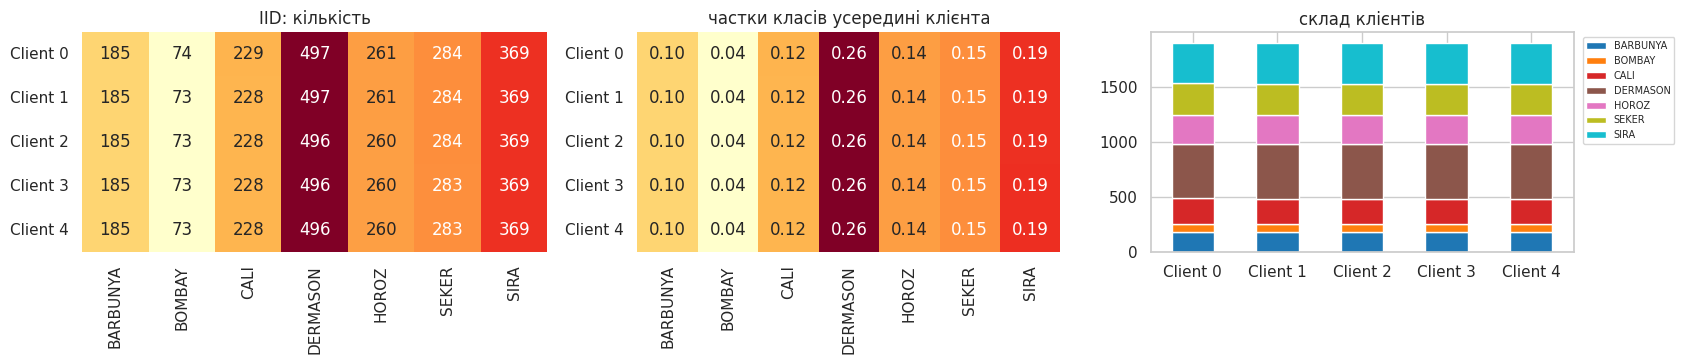

n_k = [1899, 1897, 1895, 1894, 1894] | клієнтів з n_k < 10: 0


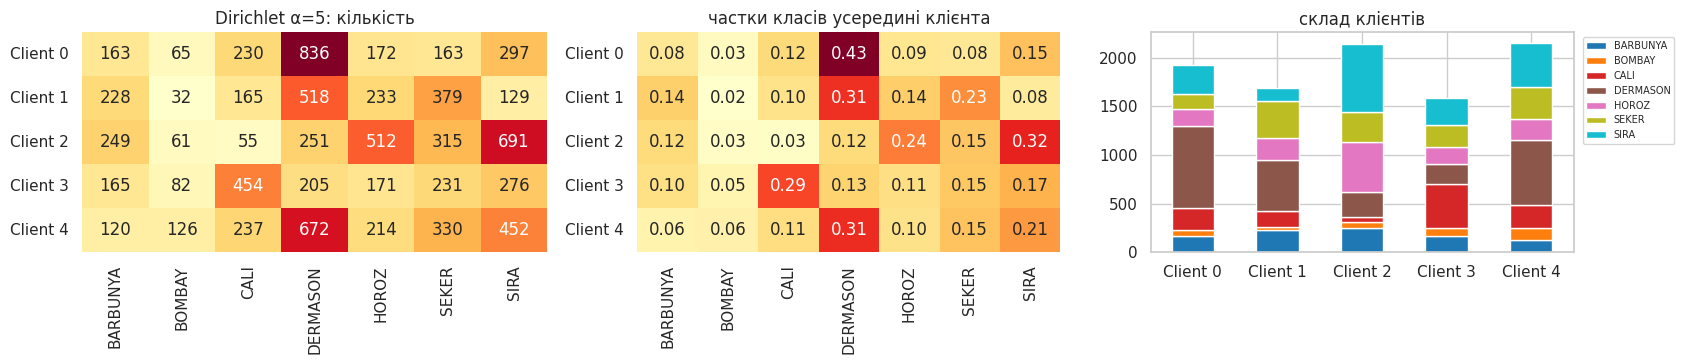

n_k = [1926, 1684, 2134, 1584, 2151] | клієнтів з n_k < 10: 0


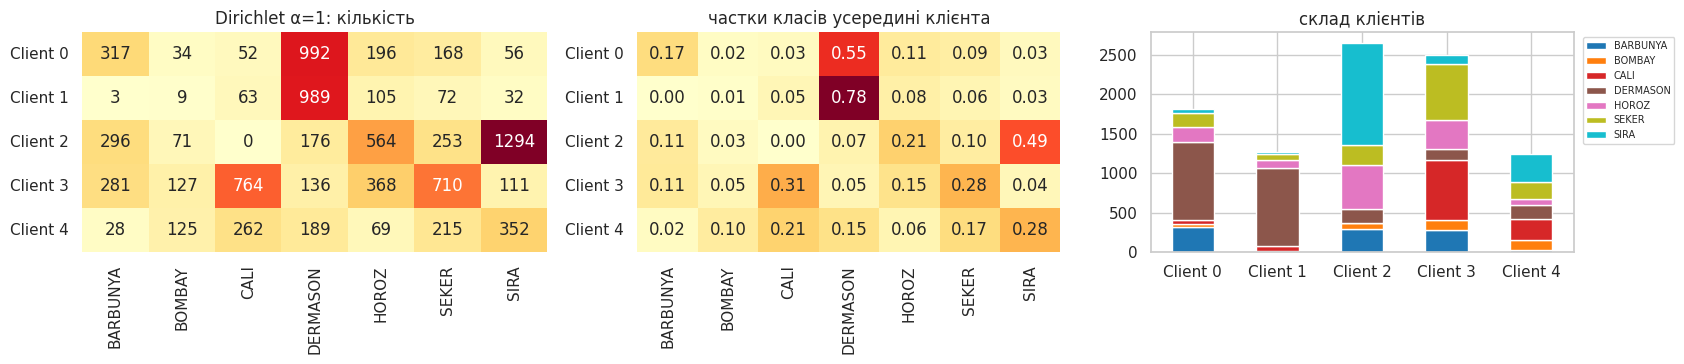

n_k = [1815, 1273, 2654, 2497, 1240] | клієнтів з n_k < 10: 0


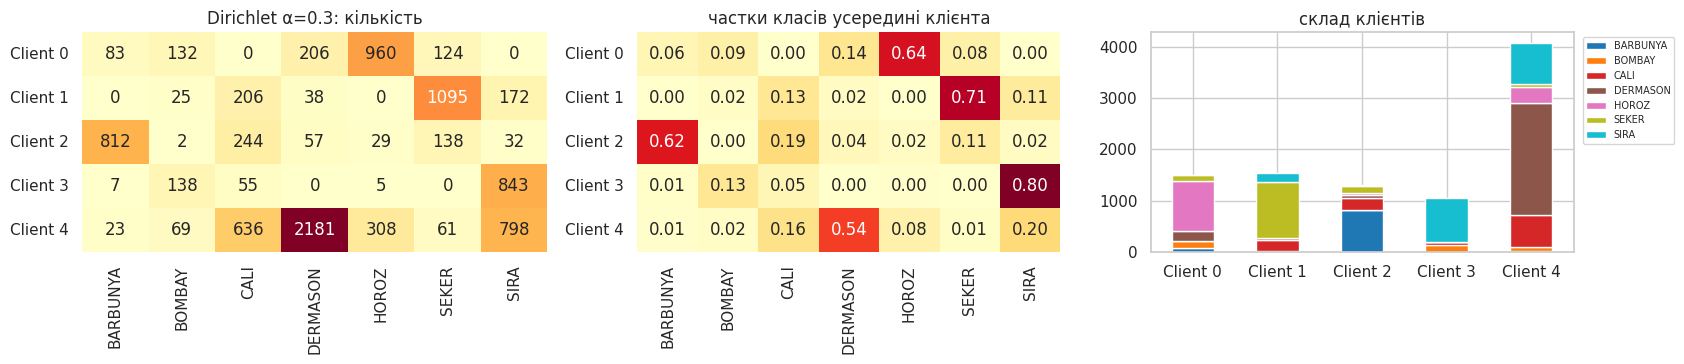

n_k = [1505, 1536, 1314, 1048, 4076] | клієнтів з n_k < 10: 0


In [15]:
def iid_partition(y, n_clients, seed=42):
    # стратифіковано: кожен клас ділиться на n_clients рівних частин
    rng = np.random.default_rng(seed)
    parts = {k: [] for k in range(n_clients)}
    for c in np.unique(y):
        idx = rng.permutation(np.where(y == c)[0])
        for k, chunk in enumerate(np.array_split(idx, n_clients)):
            parts[k].extend(chunk.tolist())
    return {k: rng.permutation(np.array(v, dtype=int)) for k, v in parts.items()}


def dirichlet_partition(y, n_clients, alpha=0.3, seed=42, min_size=10, max_tries=2000):
    rng = np.random.default_rng(seed)
    for _ in range(max_tries):
        client_indices = {k: [] for k in range(n_clients)}
        for class_id in np.unique(y):
            class_indices = np.where(y == class_id)[0]
            rng.shuffle(class_indices)
            proportions = rng.dirichlet(np.full(n_clients, alpha, dtype=float))
            cuts = (np.cumsum(proportions) * len(class_indices)).astype(int)[:-1]
            for client_id, chunk in enumerate(np.split(class_indices, cuts)):
                client_indices[client_id].extend(chunk.tolist())
        if min(len(v) for v in client_indices.values()) >= min_size:
            return {k: rng.permutation(np.array(v, dtype=int)) for k, v in client_indices.items()}
    raise RuntimeError("не вдалося отримати розбиття з min_size")


def make_partition(alpha, n_clients, seed):          # alpha=None -> IID
    return iid_partition(y_train, n_clients, seed) if alpha is None else dirichlet_partition(y_train, n_clients, alpha, seed)


def client_class_counts(y, partition, n_classes):
    matrix = np.zeros((len(partition), n_classes), dtype=int)
    for client_id, indices in partition.items():
        matrix[client_id] = np.bincount(y[indices], minlength=n_classes)
    return matrix


def show_partition(partition, y, title):
    counts = client_class_counts(y, partition, n_classes)
    cdf = pd.DataFrame(counts, index=[f"Client {i}" for i in partition], columns=class_names)
    fig, ax = plt.subplots(1, 3, figsize=(17, 3.8), gridspec_kw={"width_ratios": [1.1, 1, 1]})
    sns.heatmap(cdf, annot=True, fmt="d", cmap="YlOrRd", ax=ax[0], cbar=False); ax[0].set_title(title + ": кількість")
    sns.heatmap(cdf.div(cdf.sum(1), axis=0), annot=True, fmt=".2f", cmap="YlOrRd", ax=ax[1], cbar=False); ax[1].set_title("частки класів усередині клієнта")
    cdf.plot(kind="bar", stacked=True, ax=ax[2], colormap="tab10", legend=False); ax[2].tick_params(axis="x", rotation=0)
    ax[2].set_title("склад клієнтів"); ax[2].legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)
    plt.tight_layout(); plt.show()
    print("n_k =", counts.sum(axis=1).tolist(), "| клієнтів з n_k < 10:", int((counts.sum(axis=1) < 10).sum()))


N_CLIENTS = 5
for name, a in [("IID", None), ("Dirichlet α=5", 5.0), ("Dirichlet α=1", 1.0), ("Dirichlet α=0.3", 0.3)]:
    part = make_partition(a, N_CLIENTS, RANDOM_STATE)
    assert sorted(np.concatenate(list(part.values())).tolist()) == list(range(len(y_train)))   # кожен приклад рівно в одного клієнта
    show_partition(part, y_train, name)

### Висновок

* **IID**: клієнти мають майже однаковий розмір (≈ 1 895) і ті самі пропорції класів, що й глобальні.
* **α = 5**: розподіл близький до IID, розміри 1 584 – 2 151.
* **α = 1**: помітний перекіс; деякі класи концентруються у 1–2 клієнтів, розміри 1 240 – 2 654.
* **α = 0.3**: сильний label skew; у клієнтів відсутні цілі класи (див. п. 15), розміри від 1 048 до 4 076.

Клієнтів із n_k < 10 немає (гарантовано кодом). Чим менше α, тим більше локальна ціль $F_k$ відрізняється від глобальної, і тим сильніше це вплине на локальні моделі та FedAvg.

# 11. FedAvg

Раунд $t$: сервер розсилає $w^t$ → кожен клієнт робить $E$ локальних епох SGD **починаючи з $w^t$** (warm start) → повертає $w_k^{t+1}$ → сервер агрегує

$$w^{t+1}=\sum_{k\in S_t}\frac{n_k}{\sum_{j\in S_t}n_j}w_k^{t+1}$$

(для $W$ і $b$) → глобальна модель оцінюється на **Global Validation** (раніше рахувався loss на тренувальному пулі). Також міряємо **client drift**: $\|w_k^{t+1}-w^t\|_2$. Є опція `weighted=False` (просте середнє) та часткова участь клієнтів `client_fraction`.

In [16]:
def fedavg(client_params, client_sizes, weighted=True):
    sizes = np.asarray(client_sizes, dtype=float)
    weights = sizes / sizes.sum() if weighted else np.ones(len(sizes)) / len(sizes)
    W_avg = sum(w * W for w, (W, b) in zip(weights, client_params))
    b_avg = sum(w * b for w, (W, b) in zip(weights, client_params))
    return W_avg, b_avg


def flat_params(W, b):
    return np.concatenate([W.ravel(), b.ravel()])


def train_federated(X, y, partition, learning_rate, batch_size, reg_lambda,
                    local_epochs=5, rounds=40, seed=42, weighted=True, client_fraction=1.0,
                    X_val=None, y_val=None):
    n_clients = len(partition)
    n_features = X.shape[1]
    rng = np.random.default_rng(seed)

    global_model = MulticlassLogisticRegression(learning_rate, local_epochs, batch_size, reg_lambda, seed)
    global_model.init_params(n_features, n_classes)
    Y_val_ = one_hot(y_val, n_classes) if y_val is not None else None
    history = {"val_loss": [], "val_acc": [], "val_macro_f1": [], "drift": []}

    for round_id in range(rounds):
        if client_fraction >= 1.0:
            selected_clients = np.arange(n_clients)
        else:
            selected_clients = np.sort(rng.choice(n_clients, max(1, int(round(client_fraction * n_clients))), replace=False))

        client_params, client_sizes, drifts = [], [], []
        gW, gb = global_model.get_params()

        for client_id in selected_clients:
            indices = partition[client_id]
            local_model = MulticlassLogisticRegression(
                learning_rate, local_epochs, batch_size, reg_lambda,
                random_state=seed * 100000 + round_id * 100 + int(client_id)      # унікальне зерно для кожної пари (раунд, клієнт)
            )
            local_model.set_params(gW, gb)                                       # отримали глобальну модель від сервера
            local_model.fit(X[indices], one_hot(y[indices], n_classes), warm_start=True, record=False)

            client_params.append(local_model.get_params())
            client_sizes.append(len(indices))
            drifts.append(np.linalg.norm(flat_params(*local_model.get_params()) - flat_params(gW, gb)))

        new_W, new_b = fedavg(client_params, client_sizes, weighted)
        global_model.set_params(new_W, new_b)

        if X_val is not None:
            pred = global_model.predict(X_val)
            history["val_loss"].append(global_model.loss(X_val, Y_val_, regularize=False))
            history["val_acc"].append(np.mean(pred == y_val))
            history["val_macro_f1"].append(f1_score(y_val, pred, average="macro"))
            history["drift"].append(float(np.mean(drifts)))

    return global_model, history


def train_local_models(X, y, partition, epochs, params, seed):
    # кожна локальна модель навчається лише на даних свого клієнта (без федерації)
    models = []
    for k, idx in partition.items():
        m = MulticlassLogisticRegression(params["learning_rate"], epochs, params["batch_size"], params["reg_lambda"], seed + k)
        models.append(m.fit(X[idx], one_hot(y[idx], n_classes), record=False))
    return models


ROUNDS, E_DEFAULT = 40, 5
SEEDS = [0, 1, 2]
FL = dict(learning_rate=best_params["learning_rate"], batch_size=best_params["batch_size"], reg_lambda=best_params["reg_lambda"])

def run_fl(alpha, n_clients=N_CLIENTS, E=E_DEFAULT, seed=RANDOM_STATE, rounds=ROUNDS, weighted=True):
    part = make_partition(alpha, n_clients, seed)
    model, hist = train_federated(X_train_scaled, y_train, part, local_epochs=E, rounds=rounds, seed=seed, weighted=weighted,
                                  X_val=X_val_scaled, y_val=y_val, **FL)
    return part, model, hist

# sanity-check: після 1 раунду E=1 на IID глобальна модель вже не нуль, а після кількох раундів наближається до централізованої
_, m_chk, h_chk = run_fl(None, E=1, rounds=15)
print("FedAvg IID E=1: val accuracy за раундами 1/5/15:", [round(h_chk['val_acc'][i], 3) for i in (0, 4, 14)])

FedAvg IID E=1: val accuracy за раундами 1/5/15: [np.float64(0.914), np.float64(0.935), np.float64(0.938)]


# 12. Федеративне навчання на IID даних

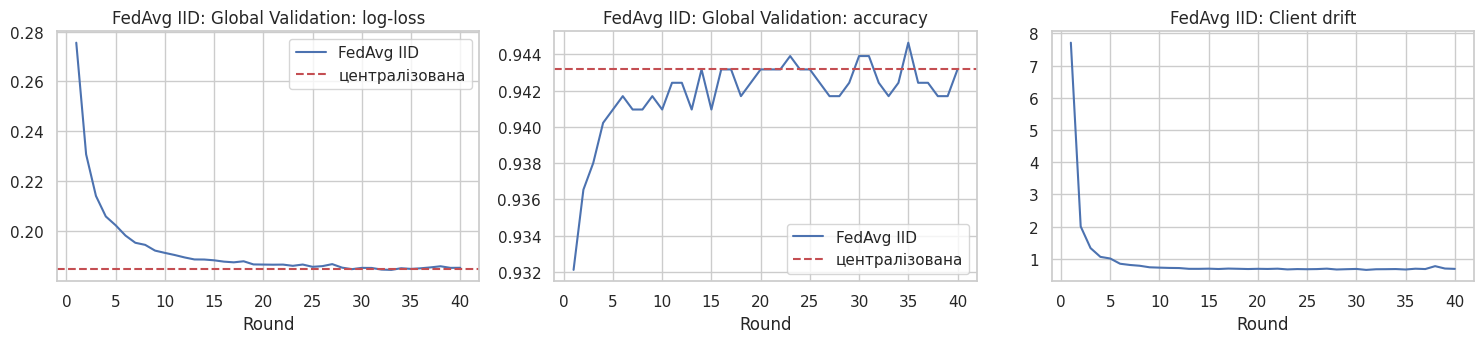

,accuracy,macro_f1,balanced_accuracy,log_loss
FedAvg IID,0.9181,0.9294,0.9292,0.2201
Centralized,0.9155,0.9272,0.9269,0.2222


In [17]:
iid_partition_main, iid_model, iid_hist = run_fl(None)
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
for a, key, t in zip(ax, ["val_loss", "val_acc", "drift"], ["Global Validation: log-loss", "Global Validation: accuracy", "Client drift"]):
    a.plot(range(1, ROUNDS + 1), iid_hist[key], label="FedAvg IID"); a.set_title("FedAvg IID: " + t); a.set_xlabel("Round")
ax[0].axhline(central_val_metrics["log_loss"], color="r", ls="--", label="централізована"); ax[1].axhline(central_val_metrics["accuracy"], color="r", ls="--", label="централізована")
ax[0].legend(); ax[1].legend(); plt.tight_layout(); plt.show()

iid_test_metrics = evaluate_model(iid_model, X_test_scaled, y_test)
display(pd.DataFrame([iid_test_metrics, central_test_metrics], index=["FedAvg IID", "Centralized"]).round(4))

### Висновок

У IID-режимі FedAvg збігається за кілька раундів і досягає якості централізованої моделі: accuracy 0,9181 проти 0,9155, macro-F1 0,9294 проти 0,9272, log-loss 0,2201 проти 0,2222 (різниця в межах шуму). Клієнтський drift після початкових раундів мінімальний. Отже, коли дані однорідні, спільне навчання через усереднення параметрів майже нічого не втрачає порівняно з об'єднанням даних, а приватність зберігається. Sanity-check: при E = 1 після першого раунду val accuracy вже 0,914 (модель не обнуляється; у початковому коді цього не було через баг з warm start).

# 13. Експеримент 1: вплив неоднорідності даних

$\alpha\in\{5,1,0.3\}$ (+ IID для довідки), $K=5$, $E=5$, 40 раундів. Результати усереднюємо за **3 зернами** (зерно змінює розбиття та ініціалізацію): один запуск не дозволяє відрізнити ефект від шуму. Для кожного налаштування також навчаємо **локальні моделі** (лише на $D_k$, стільки ж епох, скільки загалом у FL) і порівнюємо їх із глобальною.

In [18]:
LOCAL_EPOCHS = ROUNDS * E_DEFAULT
settings = [("IID", None), ("α=5", 5.0), ("α=1", 1.0), ("α=0.3", 0.3)]
rows, curves = [], {}
for name, a in settings:
    for s in SEEDS:
        part, model, hist = run_fl(a, seed=s)
        if s == SEEDS[0]: curves[name] = hist
        g = evaluate_model(model, X_test_scaled, y_test)
        locs = [evaluate_model(m, X_test_scaled, y_test) for m in train_local_models(X_train_scaled, y_train, part, LOCAL_EPOCHS, FL, s)]
        rows.append(dict(setting=name, seed=s, **{"fedavg_" + k: v for k, v in g.items()},
                         local_mean_acc=np.mean([l["accuracy"] for l in locs]),
                         local_best_acc=max(l["accuracy"] for l in locs),
                         local_mean_f1=np.mean([l["macro_f1"] for l in locs]),
                         local_mean_bacc=np.mean([l["balanced_accuracy"] for l in locs]),
                         n_locals_better_than_global=sum(l["accuracy"] > g["accuracy"] for l in locs)))
exp1 = pd.DataFrame(rows)
cols = ["fedavg_accuracy", "fedavg_macro_f1", "fedavg_balanced_accuracy", "fedavg_log_loss",
        "local_mean_acc", "local_best_acc", "local_mean_f1", "n_locals_better_than_global"]
tab1 = exp1.groupby("setting", sort=False)[cols].mean()
tab1_std = exp1.groupby("setting", sort=False)[["fedavg_accuracy", "fedavg_macro_f1"]].std().add_suffix("_std")
tab1.loc["Centralized (довідка)"] = [central_test_metrics["accuracy"], central_test_metrics["macro_f1"],
                                    central_test_metrics["balanced_accuracy"], central_test_metrics["log_loss"]] + [np.nan] * 4
display(tab1.round(4)); display(tab1_std.round(4))

,fedavg_accuracy,fedavg_macro_f1,fedavg_balanced_accuracy,fedavg_log_loss,local_mean_acc,local_best_acc,local_mean_f1,n_locals_better_than_global
setting,,,,,,,,
IID,0.9171,0.9280,0.9274,0.2201,0.9173,0.9200,0.9285,2.3333
α=5,0.9179,0.9289,0.9286,0.2210,0.9145,0.9178,0.9261,0.6667
α=1,0.9165,0.9277,0.9271,0.2223,0.8797,0.9081,0.8872,0.0000
α=0.3,0.9128,0.9250,0.9237,0.2348,0.7430,0.8389,0.7201,0.0000
Centralized (довідка),0.9155,0.9272,0.9269,0.2222,NaN,NaN,NaN,NaN


,fedavg_accuracy_std,fedavg_macro_f1_std
setting,,
IID,0.0011,0.0011
α=5,0.0014,0.0019
α=1,0.0015,0.0012
α=0.3,0.0025,0.0021


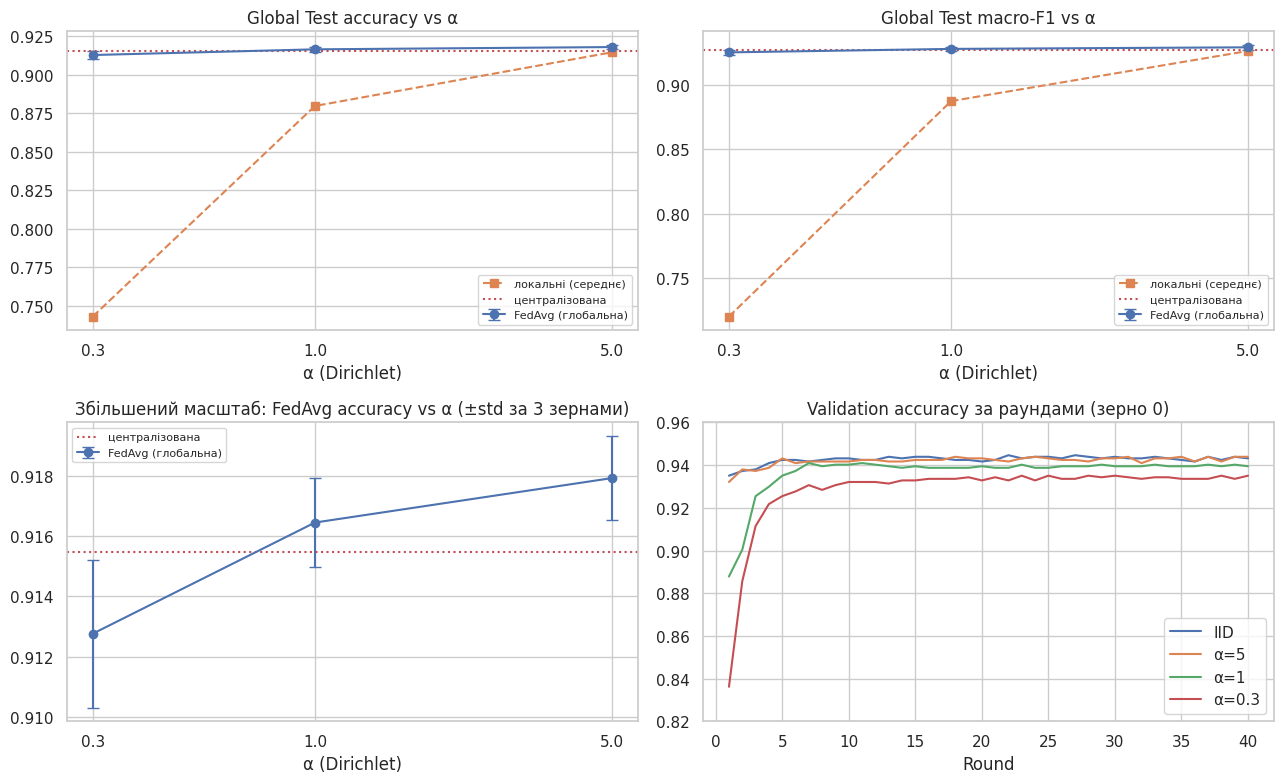

In [19]:
alphas, names = [0.3, 1.0, 5.0], ["α=0.3", "α=1", "α=5"]
fig, ax = plt.subplots(2, 2, figsize=(13, 8))
for a, (col, loc, t, ref) in zip(ax[0], [("fedavg_accuracy", "local_mean_acc", "accuracy", central_test_metrics["accuracy"]),
                                         ("fedavg_macro_f1", "local_mean_f1", "macro-F1", central_test_metrics["macro_f1"])]):
    g = exp1[exp1.setting.isin(names)].groupby("setting")[col]
    a.errorbar(alphas, [g.mean()[n] for n in names], yerr=[g.std()[n] for n in names], fmt="o-", capsize=4, label="FedAvg (глобальна)")
    a.plot(alphas, [exp1[exp1.setting == n][loc].mean() for n in names], "s--", label="локальні (середнє)")
    a.axhline(ref, color="r", ls=":", label="централізована")
    a.set_xscale("log"); a.set_xticks(alphas); a.set_xticklabels(alphas); a.set_xlabel("α (Dirichlet)"); a.set_title(f"Global Test {t} vs α"); a.legend(fontsize=8)
# збільшений масштаб: лише FedAvg
g = exp1[exp1.setting.isin(names)].groupby("setting")["fedavg_accuracy"]
ax[1, 0].errorbar(alphas, [g.mean()[n] for n in names], yerr=[g.std()[n] for n in names], fmt="o-", capsize=4, label="FedAvg (глобальна)")
ax[1, 0].axhline(central_test_metrics["accuracy"], color="r", ls=":", label="централізована")
ax[1, 0].set_xscale("log"); ax[1, 0].set_xticks(alphas); ax[1, 0].set_xticklabels(alphas); ax[1, 0].set_xlabel("α (Dirichlet)")
ax[1, 0].set_title("Збільшений масштаб: FedAvg accuracy vs α (±std за 3 зернами)"); ax[1, 0].legend(fontsize=8)
for n, h in curves.items(): ax[1, 1].plot(range(1, ROUNDS + 1), h["val_acc"], label=n)
ax[1, 1].set_title("Validation accuracy за раундами (зерно 0)"); ax[1, 1].set_xlabel("Round"); ax[1, 1].set_ylim(0.82, 0.96); ax[1, 1].legend()
plt.tight_layout(); plt.show()

### Висновок експерименту 1

| | IID | α=5 | α=1 | α=0.3 | централіз. |
|---|---|---|---|---|---|
| FedAvg accuracy | 0,9171 | 0,9179 | 0,9165 | 0,9128 | 0,9155 |
| FedAvg log-loss | 0,2201 | 0,2210 | 0,2223 | 0,2348 | 0,2222 |
| Локальні (середня accuracy) | 0,9173 | 0,9145 | 0,8797 | 0,7430 | — |

* **Глобальна FedAvg-модель майже не залежить від α**: accuracy зменшується лише на ≈ 0,4 п.п. при α = 0,3 (0,9128 проти ≈ 0,917 при IID), але ця різниця вже перевищує розкид між зернами (std ≈ 0,001–0,0025); log-loss погіршується помітніше (0,2348 проти ≈ 0,220). Швидкість збіжності також падає: на графіку val accuracy для α = 0,3 після 1-го раунду ≈ 0,84 проти ≈ 0,935 для IID.
* **Локальні моделі руйнуються при Non-IID**: 0,743 (α = 0,3), оскільки клієнт не бачив частини класів і не може їх передбачити; macro-F1 0,72.
* **Чому Non-IID шкодить**: локальні цілі мають різні оптимуми, усереднені оновлення зміщені відносно градієнта глобальної цілі (client drift); це відображають повільніша збіжність і гірший log-loss.
* **Чи може глобальна бути гіршою за централізовану?** Так, при α = 0,3 (0,9128 проти 0,9155 за accuracy; 0,2348 проти 0,2222 за log-loss), хоча різниця невелика. При IID/α = 5 різниці немає.
* **Чи може глобальна бути гіршою за деякі локальні?** На збалансованому Global Test при α ≤ 1 жодна локальна модель не обіграла глобальну (0 із 5). При IID/α = 5 в середньому 0,7–2,3 з 5 локальних моделей трохи кращі (різниця ≈ 0,1–0,3 п.п. — у межах шуму, бо дані практично однакові). Це відповідає на питання: у принципі можливо, але лише коли розподіл клієнта збігається з тестовим; в п. 17.3 це показано на локальних тестах.
* **Чесне застереження:** датасет Dry Bean майже лінійно розділимий, тому Non-IID шкодить глобальній моделі слабше, ніж у складніших задачах. Основний ефект видно у локальних моделях, log-loss та швидкості збіжності.

# 14. Експеримент 2: вплив кількості локальних епох

$E\in\{1,5,10\}$, $K=5$, у двох режимах: майже IID ($\alpha=5$) та сильний Non-IID ($\alpha=0.3$); 40 раундів, 3 зерна (раніше був лише $\alpha=0.3$ й одне зерно).

**Client drift**: надмірне віддалення локальних моделей від глобальної. При Non-IID кожен клієнт мінімізує *свою* функцію втрат $F_k$, оптимум якої відрізняється від глобального; чим більше $E$, тим далі клієнт іде до *свого* оптимуму, і тим гірше середнє локальних моделей наближає глобальний оптимум.

accuracy  macro_f1  balanced_accuracy  log_loss  mean_drift  \
alpha E                                                                 
α=0.3 1     0.9163    0.9282             0.9266    0.2421      1.1700   
      5     0.9128    0.9250             0.9237    0.2348      1.9244   
      10    0.9124    0.9248             0.9232    0.2370      2.3241   
α=5   1     0.9187    0.9301             0.9291    0.2306      0.5638   
      5     0.9179    0.9289             0.9286    0.2210      1.0560   
      10    0.9185    0.9296             0.9292    0.2199      1.4139   

          final_val_loss  
alpha E                   
α=0.3 1           0.2103  
      5           0.2056  
      10          0.2082  
α=5   1           0.1944  
      5           0.1846  
      10          0.1836

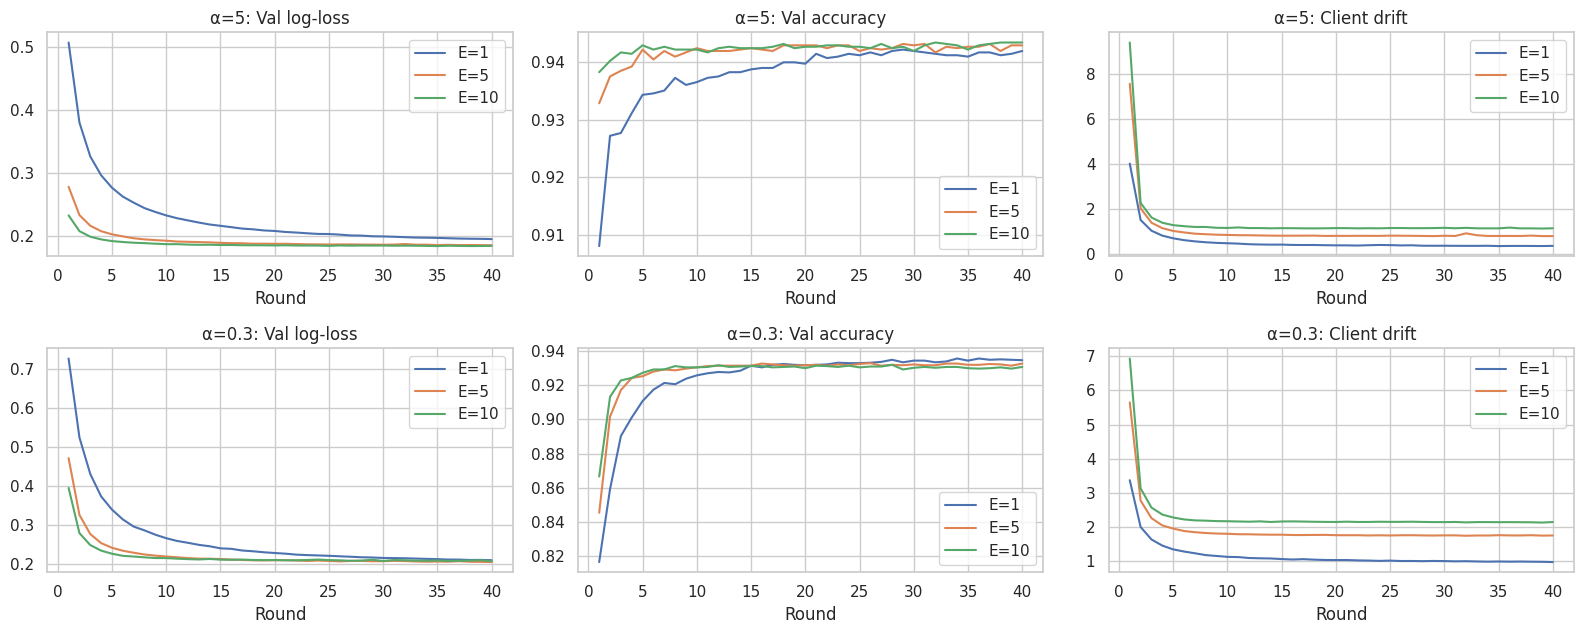

In [20]:
E_LIST = [1, 5, 10]
rows, ecurves = [], {}
for a_name, a in [("α=5", 5.0), ("α=0.3", 0.3)]:
    for E in E_LIST:
        for s in SEEDS:
            part, model, hist = run_fl(a, E=E, seed=s)
            rows.append(dict(alpha=a_name, E=E, seed=s, **evaluate_model(model, X_test_scaled, y_test),
                             mean_drift=np.mean(hist["drift"]), final_val_loss=hist["val_loss"][-1]))
            ecurves.setdefault((a_name, E), []).append(hist)
exp2 = pd.DataFrame(rows)
epoch_df = exp2.groupby(["alpha", "E"])[["accuracy", "macro_f1", "balanced_accuracy", "log_loss", "mean_drift", "final_val_loss"]].mean()
display(epoch_df.round(4))

fig, ax = plt.subplots(2, 3, figsize=(16, 6.5))
for r, a_name in enumerate(["α=5", "α=0.3"]):
    for E in E_LIST:
        hs = ecurves[(a_name, E)]
        for c, key in enumerate(["val_loss", "val_acc", "drift"]):
            ax[r, c].plot(range(1, ROUNDS + 1), np.mean([h[key] for h in hs], 0), label=f"E={E}")
    for c, t in enumerate(["Val log-loss", "Val accuracy", "Client drift"]):
        ax[r, c].set_title(f"{a_name}: {t}"); ax[r, c].set_xlabel("Round"); ax[r, c].legend()
plt.tight_layout(); plt.show()

### Висновок експерименту 2

* **Client drift зростає з E монотонно** в обох режимах: при α = 0,3 середній drift 1,17 → 1,92 → 2,32 (E = 1, 5, 10); при α = 5 — 0,56 → 1,06 → 1,41. При Non-IID drift при однаковому E приблизно вдвічі більший: клієнти тягнуть модель у різні боки.
* **Швидкість збіжності**: більше E дає швидший початок (за 1–5 раундів val log-loss у E = 10 помітно нижчий, ніж у E = 1), тобто економить комунікацію.
* **Підсумкова якість**: при α = 5 E майже не впливає (test accuracy 0,9187 / 0,9179 / 0,9185). При α = 0,3 більші E трохи гірші: accuracy 0,9163 (E = 1) → 0,9128 (E = 5) → 0,9124 (E = 10); на кривій val accuracy E = 1 виходить на вище плато (≈ 0,934), а E = 5 та 10 ≈ 0,930. Ефект малий (≈ 0,4 п.п.), але напрям відповідає теорії: велике E при Non-IID віддаляє локальні моделі від глобального оптимуму.
* **Вплив на вибір гіперпараметрів**: E = 5 — розумний компроміс (мало раундів потрібно, втрата якості мінімальна); для сильного Non-IID варто брати E = 1–5 і більше раундів.

# 15. Порівняння локальних, глобальної та централізованої моделей

Основний Non-IID сценарій: $\alpha=0.3$, $K=5$, $E=5$, зерно 42. Усі метрики на **Global Test**.

In [21]:
main_part, main_fed_model, main_fed_history = run_fl(0.3)
local_models = train_local_models(X_train_scaled, y_train, main_part, LOCAL_EPOCHS, FL, RANDOM_STATE)

rows = [{"model": "Centralized (весь FL Train Pool)", **central_test_metrics},
        {"model": "FedAvg IID", **iid_test_metrics},
        {"model": "FedAvg Non-IID α=0.3 (глобальна)", **evaluate_model(main_fed_model, X_test_scaled, y_test)}]
for k, m in enumerate(local_models):
    rows.append({"model": f"Локальна, Client {k} (n={len(main_part[k])})", **evaluate_model(m, X_test_scaled, y_test)})
comparison_df = pd.DataFrame(rows).set_index("model")
loc_only = comparison_df[comparison_df.index.str.startswith("Локальна")]
comparison_df.loc["Локальні: середнє"] = loc_only.mean()
display(comparison_df.round(4))

cmat = client_class_counts(y_train, main_part, n_classes)
print("Класи, яких у клієнта немає (=0 прикладів):")
for k in range(N_CLIENTS): print(f"  Client {k}:", [class_names[c] for c in range(n_classes) if cmat[k, c] == 0])

,accuracy,macro_f1,balanced_accuracy,log_loss
model,,,,
Centralized (весь FL Train Pool),0.9155,0.9272,0.9269,0.2222
FedAvg IID,0.9181,0.9294,0.9292,0.2201
FedAvg Non-IID α=0.3 (глобальна),0.9144,0.9242,0.9214,0.2331
"Локальна, Client 0 (n=1505)",0.6622,0.5646,0.6933,2.2937
"Локальна, Client 1 (n=1536)",0.6678,0.5670,0.6529,2.4542
"Локальна, Client 2 (n=1314)",0.8852,0.8951,0.9021,0.3356
"Локальна, Client 3 (n=1048)",0.4998,0.5538,0.6110,5.9878
"Локальна, Client 4 (n=4076)",0.8870,0.8919,0.8848,0.3190
Локальні: середнє,0.7204,0.6945,0.7488,2.2781


Класи, яких у клієнта немає (=0 прикладів):
  Client 0: ['CALI', 'SIRA']
  Client 1: ['BARBUNYA', 'HOROZ']
  Client 2: []
  Client 3: ['DERMASON', 'SEKER']
  Client 4: []


### Висновок

* Глобальна FedAvg (α = 0,3): accuracy 0,9144, macro-F1 0,9242, log-loss 0,2331 — поряд із централізованою (0,9155 / 0,9272 / 0,2222).
* **Локальні моделі суттєво гірші**: середня accuracy 0,720, macro-F1 0,695, log-loss 2,28. Клієнти 0, 1 і 3 не мають по 2 класи (наприклад, Client 3 без Dermason і Seker, найбільшого класу!): їх accuracy 0,50–0,67, а log-loss 2,3–6,0, бо модель впевнено помиляється на «невідомих» класах. Клієнти 2 і 4 мають усі класи і досягають 0,885–0,887, проте все одно поступаються глобальній (0,914).
* **Висновок для вибору підходу**: у режимі, де дані окремих клієнтів неповні, федеративне навчання дає майже якість централізованої моделі без передачі даних, тоді як локальне навчання недостатнє.

# 16. Графік навчання федеративної моделі за раундами

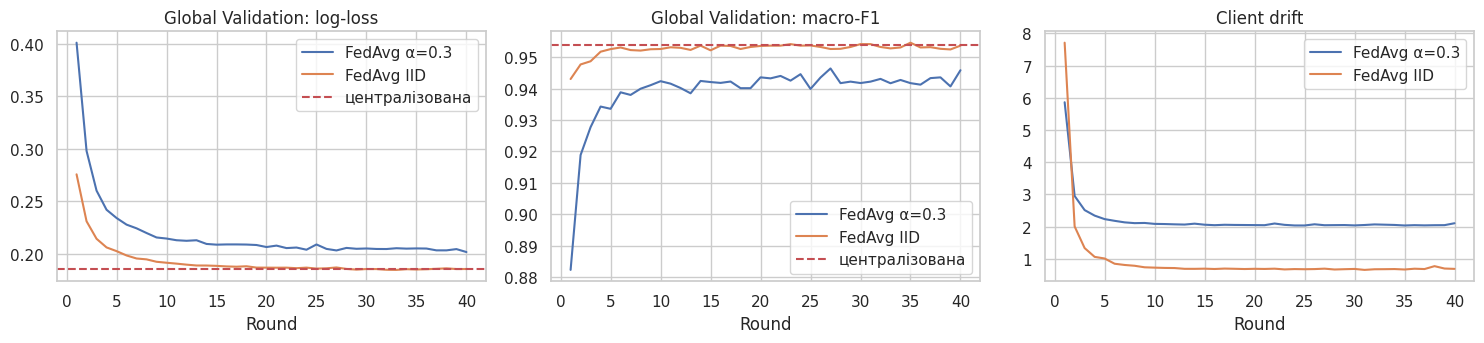

In [22]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
for a, key, t in zip(ax, ["val_loss", "val_macro_f1", "drift"], ["Global Validation: log-loss", "Global Validation: macro-F1", "Client drift"]):
    a.plot(range(1, ROUNDS + 1), main_fed_history[key], label="FedAvg α=0.3"); a.plot(range(1, ROUNDS + 1), iid_hist[key], label="FedAvg IID"); a.set_title(t); a.set_xlabel("Round")
ax[0].axhline(central_val_metrics["log_loss"], color="r", ls="--", label="централізована"); ax[1].axhline(central_val_metrics["macro_f1"], color="r", ls="--", label="централізована")
for a in ax: a.legend()
plt.tight_layout(); plt.show()

### Висновок

На графіку Global Validation: IID-крива швидко насичується й стабільна, α = 0,3 повільніша на старті та має трохи вищий loss на плато (приблизно 0,21 проти 0,19) — наслідок drift (права панель: drift при α = 0,3 значно більший, ≈ 1,8 проти ≈ 0,8 для IID). Обидві FedAvg-криві наближаються до централізованої (червона пунктирна лінія): після ≈ 10–15 раундів додаткові раунди дають мало. Тому 40 раундів достатньо; раннє зупинення за Global Validation було б доречним.

# 17. Додаткові експерименти

### 17.1 Зважене vs просте середнє (питання 11)

In [23]:
rows = []
for s in SEEDS:
    for wname, w in [("зважене (n_k)", True), ("просте середнє", False)]:
        part, model, hist = run_fl(0.3, seed=s, weighted=w)
        rows.append(dict(aggregation=wname, seed=s, sizes=[len(p) for p in part.values()], **evaluate_model(model, X_test_scaled, y_test)))
expw = pd.DataFrame(rows)
display(expw.groupby("aggregation")[["accuracy", "macro_f1", "balanced_accuracy", "log_loss"]].mean().round(4))
print("Розміри клієнтів (зерна 0,1,2):", [expw[(expw.seed == s)].sizes.iloc[0] for s in SEEDS])

,accuracy,macro_f1,balanced_accuracy,log_loss
aggregation,,,,
зважене (n_k),0.9128,0.9250,0.9237,0.2348
просте середнє,0.9114,0.9242,0.9237,0.2351


Розміри клієнтів (зерна 0,1,2): [[3659, 1853, 1926, 1401, 640], [2275, 1102, 518, 1856, 3728], [1006, 2863, 2303, 3187, 120]]


### Висновок

Для α = 0,3 клієнти мають дуже різні розміри (напр. 3 659 / 1 853 / 1 926 / 1 401 / 640, а в зерні 2 від 120 до 3 187). Зважене усереднення дає accuracy 0,9128 і log-loss 0,2348, просте 0,9114 і 0,2351. Різниця **дуже мала** (в межах шуму), але зважування не гірше. Причина малого ефекту: задача проста і всі клієнти все одно навчають модель у тому ж напрямку. Теоретично просте середнє надає малим клієнтам (n_k = 120) таку ж вагу, як великим, що й призводить до нестабільності на складніших задачах.

### 17.2 Експеримент А: вплив кількості клієнтів $K\in\{3,5,10\}$ ($\alpha=1$, $E=5$)

,accuracy,macro_f1,balanced_accuracy,log_loss,min_n_k
K,,,,,
3,0.9165,0.9294,0.9297,0.2228,2590.6667
5,0.9165,0.9277,0.9271,0.2223,1120.3333
10,0.9166,0.9278,0.9274,0.2257,443.3333


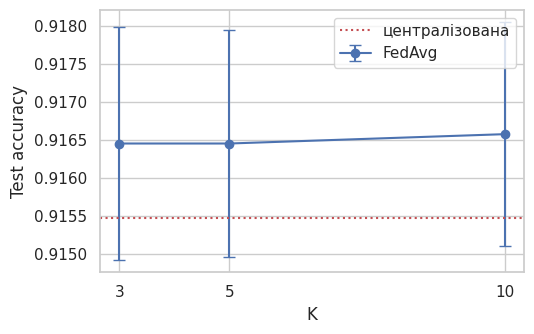

In [24]:
rows = []
for K in [3, 5, 10]:
    for s in SEEDS:
        part, model, hist = run_fl(1.0, n_clients=K, seed=s)
        rows.append(dict(K=K, seed=s, **evaluate_model(model, X_test_scaled, y_test), min_n_k=min(len(p) for p in part.values())))
expK = pd.DataFrame(rows)
tK = expK.groupby("K")[["accuracy", "macro_f1", "balanced_accuracy", "log_loss", "min_n_k"]].mean(); display(tK.round(4))
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.errorbar(tK.index, expK.groupby("K").accuracy.mean(), yerr=expK.groupby("K").accuracy.std(), fmt="o-", capsize=4, label="FedAvg")
ax.axhline(central_test_metrics["accuracy"], color="r", ls=":", label="централізована"); ax.set_xticks([3, 5, 10]); ax.set_xlabel("K"); ax.set_ylabel("Test accuracy"); ax.legend()
plt.tight_layout(); plt.show()

### Висновок

Якість майже не залежить від K: accuracy 0,9165 / 0,9165 / 0,9166, macro-F1 0,9294 / 0,9277 / 0,9278 для K = 3 / 5 / 10 (різниця в межах шуму), log-loss трохи гірший при K = 10 (0,2257 проти 0,2223–0,2228). Із зростанням K кожен клієнт має менше даних (мінімальний n_k падає з ≈ 2 600 до ≈ 440) і сильніше відрізняється від інших, тож drift і шум оновлень зростають; для цього простого датасету компенсує великий загальний обсяг. Для складніших задач і малих n_k очікується більше падіння.

### 17.3 Експеримент Б: персоналізація ($\alpha=0.3$, $K=5$)
Кожен клієнт ділить $D_k$ на локальний train (80%) та локальний test (20%). FedAvg навчається лише на локальних train; далі кожен клієнт **дотреновує** глобальну модель 2 епохи на своєму train. Порівняння на **локальних тестах** (Global Test тут не використовується).

In [25]:
local_tr, local_te = {}, {}
for k, idx in main_part.items():
    cnt = np.bincount(y_train[idx], minlength=n_classes); ok = (cnt[cnt > 0] >= 2).all()
    tr, te = train_test_split(idx, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train[idx] if ok else None)
    local_tr[k], local_te[k] = tr, te

g_model, _ = train_federated(X_train_scaled, y_train, local_tr, local_epochs=E_DEFAULT, rounds=ROUNDS, seed=RANDOM_STATE, **FL)
gW, gb = g_model.get_params()
rows = []
for k in local_tr:
    pers = MulticlassLogisticRegression(FL["learning_rate"], 2, FL["batch_size"], FL["reg_lambda"], RANDOM_STATE + k).set_params(gW, gb)
    pers.fit(X_train_scaled[local_tr[k]], one_hot(y_train[local_tr[k]], n_classes), warm_start=True, record=False)
    Xte, yte = X_train_scaled[local_te[k]], y_train[local_te[k]]
    eg, ep = evaluate_model(g_model, Xte, yte), evaluate_model(pers, Xte, yte)
    rows.append({"client": k, "n_local_test": len(yte), "acc глобальна": eg["accuracy"], "acc персоналіз.": ep["accuracy"],
                 "logloss глобальна": eg["log_loss"], "logloss персоналіз.": ep["log_loss"]})
pers_df = pd.DataFrame(rows).set_index("client"); pers_df.loc["середнє"] = pers_df.mean(); display(pers_df.round(4))

,n_local_test,acc глобальна,acc персоналіз.,logloss глобальна,logloss персоналіз.
client,,,,,
0,301.0,0.9302,0.9601,0.2441,0.1280
1,308.0,0.8994,0.9351,0.2772,0.1466
2,263.0,0.8859,0.9544,0.3069,0.1254
3,210.0,0.9190,0.9952,0.2511,0.0442
4,816.0,0.9142,0.9338,0.2008,0.1634
середнє,379.6,0.9098,0.9557,0.2560,0.1215


### Висновок

Дотренування глобальної моделі 2 епохи на локальних даних **покращило кожного з 5 клієнтів** на їхніх локальних тестах: середня accuracy 0,910 → 0,956, log-loss 0,256 → 0,122. Найбільший виграш у клієнта 3 (0,919 → 0,995) та клієнта 2 (0,886 → 0,954), оскільки їхні локальні розподіли найбільше відрізняються від глобального. Тобто у Non-IID глобальна модель — це компроміс між розподілами, а невелика локальна адаптація відновлює спеціалізацію; це відповідає на питання, коли локальна модель може перевершити глобальну.

# 18. Відповіді на теоретичні питання

### 1. Чому для багатокласової класифікації використовують softmax?
Softmax перетворює вектор логітів $Z_i\in\mathbb R^C$ на розподіл імовірностей: $P_{ic}>0$, $\sum_cP_{ic}=1$. Це природне узагальнення сигмоїди на $C>2$ (при $C=2$ зводиться до неї), вихід інтерпретується як $P(y=c\mid x)$. Він диференційовний, а його поєднання з крос-ентропією дає простий градієнт $P-Y$. Softmax інваріантний до зсуву логітів, тому віднімання максимуму рядка забезпечує числову стабільність.

### 2. Чому крос-ентропія є природною функцією втрат для логістичної регресії?
Мінімізація середньої крос-ентропії еквівалентна **максимізації правдоподібності** (MLE) категоріальної моделі $y\mid x\sim\mathrm{Cat}(\mathrm{softmax}(xW+b))$. Вона опукла за $(W,b)$, сильно штрафує впевнені помилки, а градієнт лінійний за помилкою $P-Y$ (немає «насичення», на відміну від MSE із softmax/сигмоїдою).

### 3. Чим відрізняється Ridge від Lasso?
Ridge додає $\frac\lambda2\|W\|_2^2$ (L2): рівномірно стискає ваги, рідко занулює їх точно, гладкий градієнт, добре працює з колінеарністю. Lasso додає $\lambda\|W\|_1$ (L1): дає **розріджені** розв'язки (вбудований відбір ознак), але негладкий у нулі (потрібні субградієнти/proximal-методи); при сильно корельованих ознаках вибір між ними нестабільний.

### 4. Чому параметр зсуву $b$ зазвичай не регуляризують?
Регуляризація обмежує складність (чутливість моделі до змін входу). Зсув не множиться на ознаки і лише переносить межі рішень, а не змінює їхню «кривину», тому майже не впливає на перенавчання ($C$ параметрів проти $d\cdot C$). Штраф на $b$ зміщував би прогнози до рівноймовірних класів і робив результат залежним від зсуву даних (центрування), хоча модель має бути інваріантною до нього.

### 5. Що таке Data Leakage?
Потрапляння в процес навчання/підбору моделі інформації, якої не буде під час реального використання. Наприклад, статистики скалера, порахованих на всьому датасеті, відбір ознак за таргетом на всіх даних, дублікати між train і test. Наслідок: завищена оцінка якості, що не відтворюється на нових даних. Тому порядок: **спочатку розбиття, потім усі fit-операції лише на train**.

### 6. Чому тестову вибірку не можна використовувати для підбору гіперпараметрів?
Кожен вибір «за тестом» робить тест частиною процесу навчання: гіперпараметри підганяються під його випадкові особливості (оптимістичне зміщення), і він перестає бути незалежною оцінкою. Для цього існує окрема валідація; тест лишається «запечатаним» до фінальної оцінки.

### 7. Чому параметри масштабування потрібно навчати лише на тренувальних даних?
$\mu$ і $\sigma$ також є навченими параметрами. Рахувати їх на val/test означає leakage; у реальному застосуванні нові дані ще невідомі й масштабуються за збереженою тренувальною статистикою. У федеративній постановці клієнти рахують локальні агрегати, а сервер об'єднує їх (п. 6).

### 8. Що таке федеративне навчання і які його основні переваги?
Навчання спільної моделі на даних, що **залишаються у власників**: передаються лише параметри/оновлення. Переваги: приватність (сирі дані не залишають клієнта, відповідність GDPR тощо), немає потреби централізувати великі обсяги даних, можливість використати дані організацій, які не можуть ними ділитися. Обмеження: Non-IID, комунікаційні витрати, гетерогенність клієнтів, потреба в додатковому захисті (DP, secure aggregation), бо оновлення теж можуть щось розкривати.

### 9. Чому сервер не повинен отримувати сирі дані клієнтів?
Це суть федеративного підходу: дані можуть бути конфіденційними, комерційно цінними чи регульованими законом. Якби сервер збирав дані, це була б звичайна централізована схема з усіма ризиками (витоки, єдина точка відмови, юридичні обмеження). Сервер отримує лише параметри моделей.

### 10. Чому FedAvg використовує зважування за кількістю прикладів?
Глобальна ціль $\sum_k\frac{n_k}{n}F_k(w)$ є емпіричним ризиком на *об'єднаних* даних, де кожен приклад має однакову вагу, тому внесок клієнта має бути пропорційним $n_k$. При $E=1$ і повному батчі FedAvg тоді збігається з централізованим градієнтним спуском. Великі клієнти дають точніші оцінки й мають більший вплив.

### 11. Що станеться, якщо агрегувати параметри клієнтів без зважування?
Кожен клієнт отримує вагу $1/|S_t|$ незалежно від розміру: малі (шумні й нетипові) клієнти мають непропорційно великий вплив, глобальна модель зміщується до розподілу малих клієнтів і більше не оптимізує ризик на об'єднаних даних. При однакових $n_k$ (IID) різниці немає; при нерівних розмірах якість гірша чи нестабільніша (див. п. 17.1).

### 12. Що таке Non-IID дані?
Дані клієнтів не є незалежними однаково розподіленими вибірками з одного спільного розподілу: відрізняються розподіл міток (label skew, наш випадок Dirichlet), ознак (feature skew) або обсяги ($n_k$, quantity skew). Для кожного клієнта $P_k(x,y)\ne P(x,y)$.

### 13. Чому FL може погіршуватися на Non-IID даних?
Локальні цілі $F_k$ мають *різні* оптимуми, тому локальні оновлення зміщені відносно градієнта глобальної цілі, і їхнє середнє не є оптимальним кроком до глобального мінімуму (client drift). Клієнт «забуває» класи, яких у нього немає. Результат: повільніша й нестабільніша збіжність, коливання між раундами, гірша підсумкова якість (особливо macro-F1/balanced accuracy на рідкісних класах).

### 14. Що таке клієнтський дрейф (client drift)?
Надмірне віддалення локальних моделей від глобальної під час локального навчання: кожен клієнт рухається до мінімуму власної $F_k$, а не глобальної цілі. Сума таких зсувів не збігається з рухом до глобального оптимуму, і усереднення може бути гіршим за стартову $w^t$. Вимірюємо як $\|w_k^{t+1}-w^t\|$ (див. експерименти 1 та 2).

### 15. Як кількість локальних епох впливає на глобальну модель?
Більше $E$ означає менше комунікаційних раундів для того ж прогресу (вигідно за зв'язком) і швидше початкове зниження втрат. Але при Non-IID більше $E$ збільшує drift, що призводить до вищого «плато» втрат, коливань і нижчої якості (див. експеримент 2). $E$ є компромісом між комунікацією та точністю/стабільністю.

### 16. Чи може глобальна модель бути гіршою за централізовану? Чому?
Так, за однакового бюджету зазвичай є: (а) Non-IID і client drift; (б) обмежена кількість раундів; (в) усереднення параметрів ≠ градієнтний крок на всіх даних (збігається лише при $E=1$ і повному батчі); (г) часткова участь клієнтів і шум SGD. Централізована модель — верхня межа для тієї ж архітектури; при IID різниця мала.
**Чи може глобальна бути гіршою за деякі локальні?** Так: якщо розподіл, на якому міряємо (наприклад, локальний тест клієнта), близький до даних саме цього клієнта, його спеціалізована модель може випередити «компромісну» глобальну. Це мотивує персоналізацію (п. 17.3). На збалансованому Global Test локальні моделі зазвичай програють через відсутні класи.

### 17. Які метрики краще використовувати при дисбалансі класів?
Не лише accuracy (її «тягне» мажоритарний клас). Краще: **macro-F1**, **balanced accuracy** (середній recall по класах), **log-loss** (якість імовірностей), confusion matrix та precision/recall по класах. У Non-IID це особливо важливо, бо провал на рідкісному класі майже не видно в accuracy.

# 19. Загальний висновок

У роботі реалізовано багатокласову логістичну регресію засобами NumPy (стабільний softmax, крос-ентропія, Ridge, градієнти з перевіркою, міні-батчевий SGD) і симуляцію FedAvg із зваженою агрегацією.

**Що виправлено порівняно з початковим ноутбуком.** (1) Синтаксична помилка в ARFF-завантажувачі. (2) `fit()` обнуляв ваги, тому клієнти кожного раунду тренувались з нуля, і це був не FedAvg (тепер warm start). (3) Кореляції рахувались на всьому датасеті, а відбір ознак (мультиколінеарність) не виконувався. (4) Якість FL оцінювалась train-loss, а не на Global Validation. (5) Підбір гіперпараметрів: 3 довільні конфігурації замість сітки за lr / batch / λ. (6) Min-size у Dirichlet лише перевірявся, але не гарантувався. (7) Експерименти були одноразовими (без зерен, без drift, E лише для α = 0,3). (8) Не було висновків із числами та повних відповідей на теоретичні питання.

**Головні результати (Global Test).** Централізована модель: accuracy 0,9155 / macro-F1 0,9272. FedAvg на IID: 0,9181 / 0,9294, тобто не поступається. FedAvg при α = 0,3: 0,9128 / 0,9250 (трохи гірше, log-loss 0,2348 проти 0,2222). Локальні моделі при α = 0,3: у середньому лише 0,743 accuracy, оскільки клієнти не бачать частину класів. Збільшення Non-IID уповільнює збіжність та збільшує client drift; збільшення E збільшує drift і при сильному Non-IID трохи знижує підсумкову якість (0,9163 → 0,9124 для E = 1 → 10), хоча пришвидшує перші раунди. Персоналізація підвищує accuracy на локальних тестах з 0,910 до 0,956.

**Обмеження.** Dry Bean — відносно проста, майже лінійно розділима задача, тому ефекти Non-IID на глобальну модель невеликі (десяті частки відсотка); найкраще вони видні на локальних моделях, log-loss та drift. Гіперпараметри оптимальні на межі сітки (lr = 0,3, batch = 32), а різниці в 0,1–0,4 п.п. порівнянні з розкидом між зернами (≈ 0,1–0,25 п.п.), тому їх слід інтерпретувати обережно.